# 01 - Panorama Scene Data Audit

Notebook này dùng để **audit chất lượng dataset trước khi kết luận scene có nên đem đi stitch hay không**.

Khác với notebook OpenCV stitcher:
- `PhamHungSon_15_01_data_audit.ipynb` tập trung vào **quality screening** và **giải thích nguyên nhân rủi ro**
- `PhamHungSon_15_06_opencv_scene_stitcher.ipynb` tập trung vào **kết quả stitch thật**

Bản nâng cấp này được tách thành nhiều module nhỏ. Mỗi module có:
- một markdown cell giải thích nó làm gì
- một code cell riêng để bạn đọc, sửa và chạy độc lập


## Section 1. Imports and Notebook Setup

Module này nạp toàn bộ thư viện cần thiết cho audit.

Điểm mới ở bản vá này:
- import thêm helper để đọc **inventory ảnh thật** từ thư mục scene
- không chỉ dựa vào `meta.json`
- sẵn sàng audit nhiều feature methods nếu cần (`ORB`, `SIFT`)


In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import dataclass, asdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'project_utils').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import (
    VALID_IMAGE_EXTS,
    list_all_image_files,
    list_numbered_sequence_files,
    list_scene_dirs,
    load_scene_meta as load_scene_meta_file,
    ordered_scene_files,
)

HAS_SIFT = hasattr(cv2, 'SIFT_create')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OpenCV =', cv2.__version__)
print('HAS_SIFT =', HAS_SIFT)


PROJECT_ROOT = C:\Users\PC\Downloads\Project
OpenCV = 4.9.0
HAS_SIFT = True


## Section 2. Paths and Output Layout

Module nay dinh nghia:
- noi doc du lieu da chia split (`data/split`)
- cac split se audit mac dinh de showcase (`test`, `failure_analysis`); `development` giu lai cho vong phat trien
- noi luu output audit (`outputs/audit`)
- cac thu muc con de luu anh debug neu can

Dataset dung cho notebook nay la ban split-only da upload len Google Drive:
https://drive.google.com/drive/folders/1MLb_hScN_5qY6bSoVM65Q9w8KLP_sLU9?usp=drive_link

Muc tieu la giup notebook chay duoc khi nguoi dung chi tai `data/split`, khong can co lai thu muc `data/raw`.

In [2]:
DATA_ROOT = PROJECT_ROOT / 'data' / 'split'
SPLITS_TO_AUDIT = ['test', 'failure_analysis']
DATASET_LINK = 'https://drive.google.com/drive/folders/1MLb_hScN_5qY6bSoVM65Q9w8KLP_sLU9?usp=drive_link'

OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'audit'
OUTPUT_KEYPOINT_DIR = OUTPUT_ROOT / 'keypoints'
OUTPUT_MATCH_DIR = OUTPUT_ROOT / 'matches'
OUTPUT_INLIER_DIR = OUTPUT_ROOT / 'inliers'

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_KEYPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MATCH_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_INLIER_DIR.mkdir(parents=True, exist_ok=True)

OPENCV_LOG_ROOT = PROJECT_ROOT / 'outputs' / 'openCV' / 'logs'


def discover_audit_scene_sources(split_root: Path, split_names: list[str]) -> list[dict]:
    if not split_root.exists():
        raise FileNotFoundError(
            f"Split dataset root not found: {split_root}. Download the dataset from {DATASET_LINK} "
            "and place it so data/split/test exists."
        )

    scene_sources = []
    for split_name in split_names:
        split_dir = split_root / split_name
        if not split_dir.is_dir():
            print(f"[WARN] Missing split folder: {split_dir}")
            continue
        for scene_dir in list_scene_dirs(split_dir):
            scene_sources.append({'split': split_name, 'scene_dir': scene_dir})
    return scene_sources


def attach_split(rows: list[dict], split_name: str) -> list[dict]:
    for row in rows:
        row['split'] = split_name
    return rows


def resolve_scene_dir(scene_id: str, split_name: str | None = None) -> Path:
    candidate_splits = [split_name] if split_name else SPLITS_TO_AUDIT
    matches = []
    for candidate_split in candidate_splits:
        scene_dir = DATA_ROOT / candidate_split / scene_id
        if scene_dir.is_dir():
            matches.append(scene_dir)

    if not matches:
        split_hint = f" in split '{split_name}'" if split_name else ''
        raise FileNotFoundError(f"Scene {scene_id}{split_hint} was not found under {DATA_ROOT}")
    if len(matches) > 1:
        found = ', '.join(str(path.relative_to(DATA_ROOT)) for path in matches)
        raise ValueError(f"Scene {scene_id} appears in multiple splits ({found}); set split_name explicitly.")
    return matches[0]


print('DATA_ROOT =', DATA_ROOT)
print('SPLITS_TO_AUDIT =', SPLITS_TO_AUDIT)
print('OUTPUT_ROOT =', OUTPUT_ROOT)
print('OPENCV_LOG_ROOT =', OPENCV_LOG_ROOT)


DATA_ROOT = C:\Users\PC\Downloads\Project\data\split
SPLITS_TO_AUDIT = ['test', 'failure_analysis']
OUTPUT_ROOT = C:\Users\PC\Downloads\Project\outputs\audit
OPENCV_LOG_ROOT = C:\Users\PC\Downloads\Project\outputs\openCV\logs


## Section 3. Audit Configuration and Thresholds

Đây là policy layer của notebook.

Điểm mới:
- có thể audit nhiều methods thay vì khóa cứng một method
- có audit orientation thử 4 góc quay
- có transform sanity check để bắt warp/canvas bất thường
- có recommendation sơ bộ cho phase preprocessing


In [3]:
FEATURE_METHODS_TO_AUDIT = ['orb']  # e.g. ['orb', 'sift']
if 'sift' in FEATURE_METHODS_TO_AUDIT and not HAS_SIFT:
    print("SIFT not available in this OpenCV build; removing 'sift' from FEATURE_METHODS_TO_AUDIT.")
    FEATURE_METHODS_TO_AUDIT = [method for method in FEATURE_METHODS_TO_AUDIT if method != 'sift']
if not FEATURE_METHODS_TO_AUDIT:
    FEATURE_METHODS_TO_AUDIT = ['orb']

PRIMARY_FEATURE_METHOD = FEATURE_METHODS_TO_AUDIT[0]
ORB_NFEATURES = 6000
RATIO_TEST = 0.75
RANSAC_REPROJ_THRESHOLD = 4.0
MIN_GOOD_MATCHES_FOR_H = 8
MAX_LONG_EDGE = 2200
SAVE_VISUALS = False
RUN_SKIP_PAIR_CHECK = True
MAX_SKIP_GAP = 2

TRUST_META_ORDER_WHEN_VALID = True
ENABLE_ORIENTATION_AUDIT = True
ORIENTATION_TRIALS = [0, 90, 180, 270]
ORIENTATION_MIN_INLIER_GAIN = 20
ORIENTATION_MIN_SCORE_GAIN = 0.18
ENABLE_TRANSFORM_SANITY = True
KEYPOINT_LIMIT_WARN_RATIO = 0.92
OVERSAMPLED_OVERLAP_WARN = 0.85
OVERSAMPLED_BRIGHTNESS_GAP_MAX = 12.0

THRESH = {
    'min_blur_score': 80.0,
    'warn_blur_score': 120.0,
    'min_keypoints': 150,
    'warn_keypoints': 450,
    'min_good_matches': 40,
    'warn_good_matches': 90,
    'min_inliers': 20,
    'warn_inliers': 45,
    'min_inlier_ratio': 0.35,
    'warn_inlier_ratio': 0.50,
    'max_reproj_error': 4.0,
    'warn_reproj_error': 2.5,
    'min_overlap_ratio': 0.10,
    'warn_overlap_ratio': 0.18,
    'max_brightness_gap': 50.0,
    'warn_brightness_gap': 25.0,
    'min_entropy': 5.5,
    'warn_entropy': 6.2,
    'low_brightness': 70.0,
    'high_brightness': 190.0,
    'low_contrast': 28.0,
}

SCENE_RULES = {
    'good_min_pair_score': 0.82,
    'borderline_min_pair_score': 0.60,
}

TRANSFORM_THRESH = {
    'warn_bbox_area_ratio': 2.5,
    'fail_bbox_area_ratio': 6.0,
    'warn_diag_ratio': 2.2,
    'fail_diag_ratio': 5.0,
    'warn_projected_area_ratio': 2.5,
    'fail_projected_area_ratio': 6.0,
    'extreme_aspect_ratio': 8.0,
}

print('FEATURE_METHODS_TO_AUDIT =', FEATURE_METHODS_TO_AUDIT)
print('PRIMARY_FEATURE_METHOD =', PRIMARY_FEATURE_METHOD)
print('MAX_LONG_EDGE =', MAX_LONG_EDGE)
print('RUN_SKIP_PAIR_CHECK =', RUN_SKIP_PAIR_CHECK)
print('ENABLE_ORIENTATION_AUDIT =', ENABLE_ORIENTATION_AUDIT)
print('ENABLE_TRANSFORM_SANITY =', ENABLE_TRANSFORM_SANITY)
print('KEYPOINT_LIMIT_WARN_RATIO =', KEYPOINT_LIMIT_WARN_RATIO)
print('OVERSAMPLED_OVERLAP_WARN =', OVERSAMPLED_OVERLAP_WARN)
print('SAVE_VISUALS =', SAVE_VISUALS)


FEATURE_METHODS_TO_AUDIT = ['orb']
PRIMARY_FEATURE_METHOD = orb
MAX_LONG_EDGE = 2200
RUN_SKIP_PAIR_CHECK = True
ENABLE_ORIENTATION_AUDIT = True
ENABLE_TRANSFORM_SANITY = True
KEYPOINT_LIMIT_WARN_RATIO = 0.92
OVERSAMPLED_OVERLAP_WARN = 0.85
SAVE_VISUALS = False


## Section 4. Dataset, Metadata, and Actual File Inventory

Bản cũ đã đọc `meta.json`, nhưng review đúng ở chỗ: `meta.json` không nên được tin tuyệt đối.

Vì vậy module này làm hai việc song song:
- đọc metadata nếu có
- kiểm chứng lại bằng **inventory ảnh thật trong thư mục**

Nếu `meta.json` hợp lệ thì vẫn có thể dùng thứ tự từ đó.
Nếu không, notebook sẽ fallback bằng logic thực tế hơn thay vì fail im lặng.


In [4]:
def load_opencv_summary(scene_id: str) -> dict:
    path = OPENCV_LOG_ROOT / f"{scene_id}_opencv_panorama_summary.json"
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding='utf-8'))


def extract_numbered_indices(paths: list[Path]) -> list[int]:
    indices = []
    for path in paths:
        stem = path.stem.lower()
        if stem.startswith('img_'):
            try:
                indices.append(int(stem.split('_', 1)[1]))
            except ValueError:
                continue
    return sorted(indices)


def detect_number_gaps(indices: list[int]) -> list[str]:
    if len(indices) < 2:
        return []
    gaps = []
    for left, right in zip(indices, indices[1:]):
        if right - left > 1:
            gaps.append(f"img_{left:03d}->img_{right:03d}")
    return gaps


def validate_scene_inventory(scene_dir: Path) -> dict:
    meta = load_scene_meta_file(scene_dir) or {}
    actual_files = list_all_image_files(scene_dir)
    numbered_files = list_numbered_sequence_files(scene_dir)
    actual_name_to_path = {path.name: path for path in actual_files}
    actual_names = [path.name for path in actual_files]

    meta_ordered = meta.get('ordered_files', []) or []
    duplicate_meta_entries = sorted({name for name in meta_ordered if meta_ordered.count(name) > 1})
    meta_missing_files = [name for name in meta_ordered if name not in actual_name_to_path]
    meta_has_valid_order = bool(meta_ordered) and not duplicate_meta_entries and not meta_missing_files

    if meta_has_valid_order and TRUST_META_ORDER_WHEN_VALID:
        ordered_files = [actual_name_to_path[name] for name in meta_ordered]
        order_source = 'meta'
    elif numbered_files:
        ordered_files = numbered_files
        order_source = 'numbered'
    else:
        ordered_files = actual_files
        order_source = 'alphabetical'

    ordered_name_set = {path.name for path in ordered_files}
    reference_files = [path for path in actual_files if path.name not in ordered_name_set]

    flags = []
    if meta_ordered and duplicate_meta_entries:
        flags.append('meta_duplicate_entries')
    if meta_ordered and meta_missing_files:
        flags.append('meta_missing_files')
    if meta_ordered and not meta_has_valid_order and numbered_files:
        flags.append('fallback_to_numbered_order')
    if reference_files:
        flags.append('reference_files_present')

    numbered_indices = extract_numbered_indices(numbered_files)
    numbered_gaps = detect_number_gaps(numbered_indices)
    if numbered_gaps:
        flags.append('numbered_sequence_gaps')

    if len(ordered_files) < 2:
        status = 'error'
    elif flags:
        status = 'warning'
    else:
        status = 'ok'

    return {
        'scene_id': scene_dir.name,
        'meta': meta,
        'actual_files': actual_files,
        'actual_file_names': actual_names,
        'ordered_files': ordered_files,
        'reference_files': reference_files,
        'order_source': order_source,
        'status': status,
        'flags': flags,
        'duplicate_meta_entries': duplicate_meta_entries,
        'meta_missing_files': meta_missing_files,
        'numbered_gaps': numbered_gaps,
        'used_meta_order': order_source == 'meta',
    }


def list_image_files(scene_dir: Path):
    return validate_scene_inventory(scene_dir)['ordered_files']


def list_reference_files(scene_dir: Path):
    return validate_scene_inventory(scene_dir)['reference_files']


def load_scene_meta(scene_dir: Path) -> dict:
    return validate_scene_inventory(scene_dir)['meta']


def scene_context_row(scene_dir: Path) -> dict:
    inventory = validate_scene_inventory(scene_dir)
    meta = inventory['meta']
    audit_summary = (meta or {}).get('audit_summary', {}) or {}
    stability = audit_summary.get('stability_check', {}) or {}
    opencv = load_opencv_summary(scene_dir.name)
    return {
        'scene_id': scene_dir.name,
        'num_images': len(inventory['ordered_files']),
        'actual_image_count': len(inventory['actual_files']),
        'num_reference_files': len(inventory['reference_files']),
        'reference_files': ', '.join(path.name for path in inventory['reference_files']),
        'used_meta_order': bool(inventory['used_meta_order']),
        'order_source': inventory['order_source'],
        'inventory_status': inventory['status'],
        'inventory_flags': ', '.join(inventory['flags']),
        'inventory_meta_missing_files': ', '.join(inventory['meta_missing_files']),
        'inventory_numbered_gaps': ', '.join(inventory['numbered_gaps']),
        'meta_category': meta.get('category'),
        'meta_capture_group': meta.get('capture_group'),
        'meta_difficulty': meta.get('difficulty'),
        'meta_recommended_use': meta.get('recommended_use'),
        'meta_stitcher_status': audit_summary.get('stitcher_status'),
        'meta_ok_rate': stability.get('ok_rate'),
        'meta_stability_label': stability.get('stability_label'),
        'opencv_status_name': opencv.get('status_name'),
        'opencv_panorama_shape': opencv.get('panorama_shape'),
    }


## Section 5. Actual Data Validation and Ordering Resolution

Module này là điểm vá quan trọng nhất theo review.

Mục tiêu:
- xác minh scene từ **ảnh thật**
- chỉ dùng `meta.json` khi order trong đó thực sự hợp lệ
- ghi lại cờ cảnh báo như:
  - thiếu file trong meta
  - fallback sang numbered order
  - có numbered gaps
  - có reference files ngoài chain chính

Nhờ đó audit sẽ bớt lệ thuộc vào metadata cũ hoặc metadata sai.


In [5]:
def inventory_gate_label(scene_context: dict) -> str:
    status = scene_context.get('inventory_status')
    if status == 'error':
        return 'inventory_blocked'
    if status == 'warning':
        return 'inventory_review'
    return 'inventory_ok'


def should_trust_scene_order(scene_context: dict) -> bool:
    if scene_context.get('inventory_status') == 'error':
        return False
    return scene_context.get('order_source') in {'meta', 'numbered', 'alphabetical'}


def summarize_inventory(scene_dir: Path) -> dict:
    context = scene_context_row(scene_dir)
    context['inventory_gate'] = inventory_gate_label(context)
    context['order_trusted'] = should_trust_scene_order(context)
    return context


## Section 6. Image Loading, Resize, and Image-Level Metrics

Đây là layer đánh giá từng ảnh.

Review gợi ý nên chuẩn bị dữ liệu cho phase preprocessing, nên module này ngoài metric cũ còn sinh:
- gợi ý preprocess ở mức ảnh
- cờ cảnh báo ảnh quá mờ / quá tối / quá phẳng


In [6]:
def resize_long_edge(image_bgr: np.ndarray, max_long_edge: int) -> np.ndarray:
    height, width = image_bgr.shape[:2]
    long_edge = max(height, width)
    if long_edge <= max_long_edge:
        return image_bgr
    scale = max_long_edge / long_edge
    return cv2.resize(
        image_bgr,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )


def load_bgr(path: Path, max_long_edge: int = MAX_LONG_EDGE):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    return resize_long_edge(image, max_long_edge)


def save_bgr(path: Path, image_bgr: np.ndarray) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(str(path), image_bgr)
    if not ok:
        raise IOError(f"Could not write image: {path}")


def show_bgr(image_bgr: np.ndarray, title: str = '') -> None:
    plt.figure(figsize=(6, 4))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_gray(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)


def brightness_mean(gray):
    return float(gray.mean())


def contrast_std(gray):
    return float(gray.std())


def blur_score_laplacian(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def entropy_bits(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel().astype(np.float64)
    prob = hist / max(hist.sum(), 1.0)
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())


def normalize_score(value, *, good_if_high, good_threshold, bad_threshold):
    if value is None or not np.isfinite(value):
        return 0.0
    if good_if_high:
        if value >= good_threshold:
            return 1.0
        if value <= bad_threshold:
            return 0.0
        return float((value - bad_threshold) / max(good_threshold - bad_threshold, 1e-9))
    if value <= good_threshold:
        return 1.0
    if value >= bad_threshold:
        return 0.0
    return float((bad_threshold - value) / max(bad_threshold - good_threshold, 1e-9))


def soft_score_high(value, floor, ceiling, gamma=0.8):
    if value is None or not np.isfinite(value):
        return 0.0
    if ceiling <= floor:
        return float(value > floor)
    clamped = float(np.clip(value, floor, ceiling))
    scaled = (clamped - floor) / max(ceiling - floor, 1e-9)
    return float(np.clip(scaled, 0.0, 1.0) ** gamma)


def soft_score_low(value, good_ceiling, bad_ceiling, gamma=0.8):
    if value is None or not np.isfinite(value):
        return 0.0
    if bad_ceiling <= good_ceiling:
        return float(value <= good_ceiling)
    clamped = float(np.clip(value, good_ceiling, bad_ceiling))
    scaled = 1.0 - ((clamped - good_ceiling) / max(bad_ceiling - good_ceiling, 1e-9))
    return float(np.clip(scaled, 0.0, 1.0) ** gamma)


def overlap_score_for_stitching(overlap_ratio):
    if overlap_ratio is None or not np.isfinite(overlap_ratio):
        return 0.0
    overlap_ratio = float(overlap_ratio)
    if overlap_ratio <= 0.05:
        return 0.0
    if overlap_ratio <= 0.20:
        return float(0.6 * (overlap_ratio - 0.05) / 0.15)
    if overlap_ratio <= 0.75:
        return float(0.6 + 0.4 * (overlap_ratio - 0.20) / 0.55)
    if overlap_ratio <= 0.95:
        return float(1.0 - 0.20 * (overlap_ratio - 0.75) / 0.20)
    return 0.75


def score_image_metrics(blur, n_keypoints, entropy):
    s_blur = soft_score_high(
        blur,
        floor=max(10.0, THRESH['min_blur_score'] * 0.25),
        ceiling=max(800.0, THRESH['warn_blur_score'] * 8),
        gamma=0.75,
    )
    s_keypoints = soft_score_high(
        n_keypoints,
        floor=max(20, int(THRESH['min_keypoints'] * 0.2)),
        ceiling=max(float(ORB_NFEATURES), THRESH['warn_keypoints'] * 6),
        gamma=0.90,
    )
    s_entropy = soft_score_high(
        entropy,
        floor=max(2.0, THRESH['min_entropy'] - 1.5),
        ceiling=7.8,
        gamma=0.85,
    )
    return float(0.40 * s_blur + 0.35 * s_keypoints + 0.25 * s_entropy)


def recommend_image_preprocess(brightness, contrast, blur, entropy, n_keypoints):
    recs = []
    if blur < THRESH['min_blur_score'] * 0.5:
        recs.append('retake_or_drop_blurry_image')
    elif blur < THRESH['warn_blur_score']:
        recs.append('mild_sharpen_trial')

    if brightness < THRESH['low_brightness']:
        recs.append('gamma_or_brightness_lift')
    elif brightness > THRESH['high_brightness']:
        recs.append('highlight_clipping_review')

    if contrast < THRESH['low_contrast'] or entropy < THRESH['min_entropy']:
        recs.append('clahe_or_local_contrast_boost')

    if n_keypoints < THRESH['min_keypoints']:
        recs.append('low_texture_limited_recoverability')

    return recs


## Section 7. Image-Level Flags and Preprocessing Outlook

Module nhỏ này chuyển image metrics thành cờ dễ đọc hơn.

Nó không quyết định scene thành công hay thất bại, nhưng rất hữu ích để:
- biết ảnh nào nên bỏ
- biết ảnh nào đáng thử CLAHE / brightness lift / sharpen nhẹ


In [7]:
def image_issue_flags(brightness, contrast, blur, entropy, n_keypoints):
    flags = []
    if blur < THRESH['min_blur_score']:
        flags.append('blurry')
    if brightness < THRESH['low_brightness']:
        flags.append('too_dark')
    if brightness > THRESH['high_brightness']:
        flags.append('too_bright')
    if contrast < THRESH['low_contrast']:
        flags.append('low_contrast')
    if entropy < THRESH['min_entropy']:
        flags.append('low_texture_signal')
    if n_keypoints < THRESH['min_keypoints']:
        flags.append('few_keypoints')
    if n_keypoints >= int(ORB_NFEATURES * KEYPOINT_LIMIT_WARN_RATIO):
        flags.append('keypoint_metric_capped')
    return flags


## Section 8. Feature Extraction and Pair Geometry

Module này vẫn là xương sống của audit, nhưng giờ nó chuẩn bị dữ liệu cho:
- nhiều feature methods
- orientation trial
- transform sanity

Nói ngắn gọn: ngoài việc hỏi pair này match được không, notebook còn hỏi:
- nếu xoay ảnh thì có cải thiện mạnh không?
- homography này có dẫn đến warp/canvas bất thường không?


In [8]:
def make_feature_detector(method='orb'):
    method = method.lower()
    if method == 'orb':
        return cv2.ORB_create(nfeatures=ORB_NFEATURES)
    if method == 'sift':
        if hasattr(cv2, 'SIFT_create'):
            return cv2.SIFT_create(nfeatures=4000)
        raise RuntimeError('SIFT is not available in this OpenCV build.')
    raise ValueError("method must be 'orb' or 'sift'")


def make_matcher(method='orb'):
    method = method.lower()
    if method == 'orb':
        return cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    if method == 'sift':
        return cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    raise ValueError("method must be 'orb' or 'sift'")


def detect_and_describe(gray, method='orb'):
    detector = make_feature_detector(method)
    keypoints, descriptors = detector.detectAndCompute(gray, None)
    if keypoints is None:
        keypoints = []
    return keypoints, descriptors


def knn_ratio_match(des1, des2, method='orb', ratio=0.75):
    if des1 is None or des2 is None or len(des1) == 0 or len(des2) == 0:
        return [], []
    matcher = make_matcher(method)
    knn = matcher.knnMatch(des1, des2, k=2)
    good = []
    for pair in knn:
        if len(pair) < 2:
            continue
        first, second = pair
        if first.distance < ratio * second.distance:
            good.append(first)
    return knn, good


def keypoints_to_xy(keypoints, matches, *, query=True):
    pts = []
    for match in matches:
        index = match.queryIdx if query else match.trainIdx
        pts.append(keypoints[index].pt)
    return np.float32(pts).reshape(-1, 1, 2)


def estimate_homography(kp1, kp2, good_matches, reproj_thresh=RANSAC_REPROJ_THRESHOLD):
    if len(good_matches) < MIN_GOOD_MATCHES_FOR_H:
        return None, None
    src_pts = keypoints_to_xy(kp1, good_matches, query=True)
    dst_pts = keypoints_to_xy(kp2, good_matches, query=False)
    homography, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_thresh)
    return homography, mask


def reprojection_error(kp1, kp2, matches, homography, inlier_mask):
    if homography is None or inlier_mask is None:
        return float('inf')
    keep = inlier_mask.ravel().astype(bool)
    if keep.sum() == 0:
        return float('inf')
    inlier_matches = [match for match, is_inlier in zip(matches, keep) if is_inlier]
    src = keypoints_to_xy(kp1, inlier_matches, query=True)
    dst = keypoints_to_xy(kp2, inlier_matches, query=False)
    projected = cv2.perspectiveTransform(src, homography)
    error = np.linalg.norm(projected - dst, axis=2).reshape(-1)
    return float(np.median(error)) if len(error) else float('inf')


def estimate_overlap_ratio(shape1, shape2, homography):
    height1, width1 = shape1[:2]
    height2, width2 = shape2[:2]
    mask1 = np.ones((height1, width1), dtype=np.uint8) * 255
    warped = cv2.warpPerspective(mask1, homography, (width2, height2))
    overlap_pixels = int(np.count_nonzero(warped > 0))
    return float(overlap_pixels / max(height2 * width2, 1))


def analyze_pair(image_a_bgr, image_b_bgr, image_a_name, image_b_name, *, feature_method=PRIMARY_FEATURE_METHOD, ratio_test=RATIO_TEST):
    gray_a = to_gray(image_a_bgr)
    gray_b = to_gray(image_b_bgr)
    kp_a, des_a = detect_and_describe(gray_a, method=feature_method)
    kp_b, des_b = detect_and_describe(gray_b, method=feature_method)
    knn, good = knn_ratio_match(des_a, des_b, method=feature_method, ratio=ratio_test)
    homography, mask = estimate_homography(kp_a, kp_b, good, reproj_thresh=RANSAC_REPROJ_THRESHOLD)
    homography_ok = homography is not None and mask is not None

    if homography_ok:
        inliers = int(mask.sum())
        inlier_ratio = float(inliers / max(len(good), 1))
        reproj = reprojection_error(kp_a, kp_b, good, homography, mask)
        overlap = estimate_overlap_ratio(gray_a.shape, gray_b.shape, homography)
    else:
        inliers = 0
        inlier_ratio = 0.0
        reproj = float('inf')
        overlap = 0.0

    brightness_gap = abs(brightness_mean(gray_a) - brightness_mean(gray_b))

    return {
        'feature_method': feature_method,
        'image_a': image_a_name,
        'image_b': image_b_name,
        'raw_knn_pairs': int(len(knn)),
        'good_matches': int(len(good)),
        'homography_ok': bool(homography_ok),
        'inliers': int(inliers),
        'inlier_ratio': float(inlier_ratio),
        'reprojection_error': float(reproj),
        'overlap_ratio': float(overlap),
        'brightness_gap': float(brightness_gap),
        '_kp_a': kp_a,
        '_kp_b': kp_b,
        '_good_matches': good,
        '_mask': mask,
        '_H': homography,
    }


def draw_keypoints_image(image_bgr, keypoints):
    return cv2.drawKeypoints(
        image_bgr,
        keypoints,
        None,
        color=(80, 220, 120),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )


def draw_matches_image(image_a_bgr, kp_a, image_b_bgr, kp_b, matches, max_draw=80):
    keep = list(matches[:max_draw])
    return cv2.drawMatches(
        image_a_bgr,
        kp_a,
        image_b_bgr,
        kp_b,
        keep,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )


def draw_inlier_matches_image(image_a_bgr, kp_a, image_b_bgr, kp_b, matches, inlier_mask, max_draw=80):
    if inlier_mask is None:
        return draw_matches_image(image_a_bgr, kp_a, image_b_bgr, kp_b, matches, max_draw=max_draw)
    keep = [match for match, is_inlier in zip(matches, inlier_mask.ravel().astype(bool)) if is_inlier][:max_draw]
    return cv2.drawMatches(
        image_a_bgr,
        kp_a,
        image_b_bgr,
        kp_b,
        keep,
        None,
        matchColor=(0, 255, 0),
        singlePointColor=(160, 160, 160),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )


## Section 9. Orientation Audit and Transform Sanity

Đây là phần vá trực tiếp theo review:

- `orientation_trial_score`: thử xoay ảnh `0 / 90 / 180 / 270` độ để xem orientation hiện tại có đáng nghi không
- `transform_extent_sanity`: kiểm tra projected corners, canvas inflation, aspect explosion

Mục tiêu là bắt những scene mà:
- pair metrics trông tạm ổn
- nhưng warp/homography thực tế lại rất đáng nghi


In [9]:
def pair_quality_score_from_values(good_matches, inliers, inlier_ratio, reproj_err, overlap_ratio, brightness_gap):
    s_good = soft_score_high(
        good_matches,
        floor=max(5, THRESH['min_good_matches'] * 0.25),
        ceiling=max(600.0, THRESH['warn_good_matches'] * 12),
        gamma=0.85,
    )
    s_inliers = soft_score_high(
        inliers,
        floor=max(4, THRESH['min_inliers'] * 0.25),
        ceiling=max(250.0, THRESH['warn_inliers'] * 10),
        gamma=0.85,
    )
    s_ratio = soft_score_high(
        inlier_ratio,
        floor=max(0.05, THRESH['min_inlier_ratio'] * 0.3),
        ceiling=0.98,
        gamma=0.90,
    )
    s_reproj = soft_score_low(
        reproj_err,
        good_ceiling=0.75,
        bad_ceiling=max(THRESH['max_reproj_error'] * 3, THRESH['max_reproj_error'] + 5),
        gamma=0.90,
    )
    s_overlap = overlap_score_for_stitching(overlap_ratio)
    s_brightness = soft_score_low(
        brightness_gap,
        good_ceiling=8.0,
        bad_ceiling=max(THRESH['max_brightness_gap'] * 2, THRESH['max_brightness_gap'] + 40),
        gamma=0.85,
    )
    return float(0.15 * s_good + 0.18 * s_inliers + 0.25 * s_ratio + 0.18 * s_reproj + 0.14 * s_overlap + 0.10 * s_brightness)


def rotate_bgr(image_bgr: np.ndarray, angle: int) -> np.ndarray:
    angle = int(angle) % 360
    if angle == 0:
        return image_bgr.copy()
    if angle == 90:
        return cv2.rotate(image_bgr, cv2.ROTATE_90_CLOCKWISE)
    if angle == 180:
        return cv2.rotate(image_bgr, cv2.ROTATE_180)
    if angle == 270:
        return cv2.rotate(image_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)
    raise ValueError(f'Unsupported rotation angle: {angle}')


def polygon_area(points: np.ndarray) -> float:
    if points is None or len(points) < 3:
        return 0.0
    x = points[:, 0]
    y = points[:, 1]
    return float(0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))


def transform_sanity_from_homography(shape_a, shape_b, homography):
    default = {
        'bbox_area_ratio': np.nan,
        'projected_area_ratio': np.nan,
        'diag_ratio': np.nan,
        'aspect_ratio': np.nan,
        'label': 'fail',
        'flags': ['homography_missing'],
        'projected_corners': [],
    }
    if homography is None:
        return default

    height_a, width_a = shape_a[:2]
    height_b, width_b = shape_b[:2]
    corners = np.float32([[0, 0], [width_a, 0], [width_a, height_a], [0, height_a]]).reshape(-1, 1, 2)
    try:
        projected = cv2.perspectiveTransform(corners, homography).reshape(-1, 2)
    except cv2.error:
        default['flags'] = ['transform_projection_error']
        return default

    if not np.isfinite(projected).all():
        default['flags'] = ['non_finite_projection']
        return default

    min_xy = projected.min(axis=0)
    max_xy = projected.max(axis=0)
    bbox_w = float(max(max_xy[0] - min_xy[0], 0.0))
    bbox_h = float(max(max_xy[1] - min_xy[1], 0.0))
    bbox_area = float(bbox_w * bbox_h)
    target_area = float(max(width_b * height_b, 1))
    bbox_area_ratio = bbox_area / target_area
    projected_area = polygon_area(projected)
    projected_area_ratio = projected_area / target_area
    bbox_diag = float(np.hypot(bbox_w, bbox_h))
    target_diag = float(max(np.hypot(width_b, height_b), 1.0))
    diag_ratio = bbox_diag / target_diag
    aspect_ratio = float(max(bbox_w, bbox_h) / max(min(bbox_w, bbox_h), 1e-6))

    flags = []
    if bbox_area_ratio >= TRANSFORM_THRESH['fail_bbox_area_ratio']:
        flags.append('bbox_area_explosion')
    elif bbox_area_ratio >= TRANSFORM_THRESH['warn_bbox_area_ratio']:
        flags.append('bbox_area_inflation')

    if projected_area_ratio >= TRANSFORM_THRESH['fail_projected_area_ratio']:
        flags.append('projected_area_explosion')
    elif projected_area_ratio >= TRANSFORM_THRESH['warn_projected_area_ratio']:
        flags.append('projected_area_inflation')

    if diag_ratio >= TRANSFORM_THRESH['fail_diag_ratio']:
        flags.append('diag_explosion')
    elif diag_ratio >= TRANSFORM_THRESH['warn_diag_ratio']:
        flags.append('diag_inflation')

    if aspect_ratio >= TRANSFORM_THRESH['extreme_aspect_ratio']:
        flags.append('extreme_aspect_ratio')

    label = 'ok'
    if any(flag in flags for flag in ['bbox_area_explosion', 'projected_area_explosion', 'diag_explosion', 'extreme_aspect_ratio']):
        label = 'fail'
    elif flags:
        label = 'warn'

    return {
        'bbox_area_ratio': float(bbox_area_ratio),
        'projected_area_ratio': float(projected_area_ratio),
        'diag_ratio': float(diag_ratio),
        'aspect_ratio': float(aspect_ratio),
        'label': label,
        'flags': flags,
        'projected_corners': projected.round(2).tolist(),
    }


def orientation_trial_summary(image_a_bgr, image_b_bgr, image_a_name, image_b_name, *, feature_method=PRIMARY_FEATURE_METHOD):
    if not ENABLE_ORIENTATION_AUDIT:
        return {
            'best_angle': 0,
            'orientation_suspect': False,
            'inlier_gain': 0,
            'score_gain': 0.0,
            'trials_json': '[]',
        }

    trials = []
    for angle in ORIENTATION_TRIALS:
        rotated_b = rotate_bgr(image_b_bgr, angle)
        result = analyze_pair(image_a_bgr, rotated_b, image_a_name, image_b_name, feature_method=feature_method)
        pair_score = pair_quality_score_from_values(
            result['good_matches'],
            result['inliers'],
            result['inlier_ratio'],
            result['reprojection_error'],
            result['overlap_ratio'],
            result['brightness_gap'],
        ) if result['homography_ok'] else 0.0
        trials.append({
            'angle': int(angle),
            'pair_score': float(pair_score),
            'inliers': int(result['inliers']),
            'good_matches': int(result['good_matches']),
            'homography_ok': bool(result['homography_ok']),
        })

    base = next((trial for trial in trials if trial['angle'] == 0), trials[0])
    best = max(trials, key=lambda trial: (trial['pair_score'], trial['inliers'], trial['good_matches'], trial['angle'] == 0))
    inlier_gain = int(best['inliers'] - base['inliers'])
    score_gain = float(best['pair_score'] - base['pair_score'])
    orientation_suspect = bool(
        best['angle'] != 0
        and (
            inlier_gain >= ORIENTATION_MIN_INLIER_GAIN
            or score_gain >= ORIENTATION_MIN_SCORE_GAIN
        )
    )
    return {
        'best_angle': int(best['angle']),
        'orientation_suspect': orientation_suspect,
        'inlier_gain': int(inlier_gain),
        'score_gain': float(score_gain),
        'trials_json': json.dumps(trials),
    }


## Section 10. Pair Scoring, Failure Logic, and Preprocessing Recommendations

Đây là nơi notebook biến metric thành quyết định thực tế hơn.

Điểm mới của bản vá:
- pair bị phạt thêm nếu `transform sanity` xấu
- có flag nghi ngờ `rotation mismatch`
- có `preprocess recommendation` ở cả pair-level và scene-level
- scene classification sẽ nhìn cả inventory, adjacent pairs, và skip-pairs


In [10]:
def score_pair_metrics(good_matches, inliers, inlier_ratio, reproj_err, overlap_ratio, brightness_gap):
    return pair_quality_score_from_values(good_matches, inliers, inlier_ratio, reproj_err, overlap_ratio, brightness_gap)


def parse_recommendation_text(text: str) -> list[str]:
    if not text:
        return []
    return [item.strip() for item in str(text).split(',') if item.strip()]


def is_oversampled_pair(row: dict) -> bool:
    return bool(
        row.get('pair_gap', 1) == 1
        and row.get('overlap_ratio', 0.0) >= OVERSAMPLED_OVERLAP_WARN
        and row.get('brightness_gap', 999.0) <= OVERSAMPLED_BRIGHTNESS_GAP_MAX
        and row.get('pair_score', 0.0) >= 0.85
    )


def pair_issue_flags(row: dict) -> list[str]:
    flags = []
    if not row['homography_ok']:
        flags.append('homography_failed')
    if row['good_matches'] < THRESH['min_good_matches']:
        flags.append('too_few_good_matches')
    if row['inliers'] < THRESH['min_inliers']:
        flags.append('too_few_inliers')
    if row['inlier_ratio'] < THRESH['min_inlier_ratio']:
        flags.append('low_inlier_ratio')
    if row['overlap_ratio'] < THRESH['min_overlap_ratio']:
        flags.append('insufficient_overlap')
    if row['reprojection_error'] > THRESH['max_reproj_error']:
        flags.append('high_reprojection_error')
    if row['brightness_gap'] > THRESH['max_brightness_gap']:
        flags.append('large_brightness_gap')
    if row.get('orientation_suspect'):
        flags.append('rotation_mismatch_suspected')
    if row.get('transform_sanity_label') == 'warn':
        flags.append('transform_questionable')
    if row.get('transform_sanity_label') == 'fail':
        flags.append('transform_unstable')
    if is_oversampled_pair(row):
        flags.append('possible_near_duplicate_pair')
    return flags


def classify_pair(row: dict) -> str:
    hard_fail = (
        (not row['homography_ok'])
        or row['good_matches'] < THRESH['min_good_matches']
        or row['inliers'] < THRESH['min_inliers']
        or row['inlier_ratio'] < THRESH['min_inlier_ratio']
        or row['overlap_ratio'] < THRESH['min_overlap_ratio']
        or row['reprojection_error'] > THRESH['max_reproj_error']
        or row.get('transform_sanity_label') == 'fail'
    )
    if hard_fail:
        return 'fail'

    weak_warn = (
        row['good_matches'] < THRESH['warn_good_matches']
        or row['inliers'] < THRESH['warn_inliers']
        or row['inlier_ratio'] < THRESH['warn_inlier_ratio']
        or row['overlap_ratio'] < THRESH['warn_overlap_ratio']
        or row['reprojection_error'] > THRESH['warn_reproj_error']
        or row['brightness_gap'] > THRESH['warn_brightness_gap']
        or (row.get('orientation_suspect', False) and row.get('pair_score', 0.0) < 0.90)
        or (row.get('transform_sanity_label') == 'warn' and row.get('pair_score', 0.0) < 0.90)
    )
    if weak_warn:
        return 'weak'

    if row['pair_score'] >= SCENE_RULES['good_min_pair_score']:
        return 'strong'
    return 'ok'


def recommend_pair_preprocess(row: dict, feature_method: str) -> list[str]:
    recs = []
    if row.get('orientation_suspect'):
        recs.append('check_rotation_or_capture_order')
    if row['brightness_gap'] > THRESH['warn_brightness_gap']:
        recs.append('brightness_normalization_trial')
    if row.get('transform_sanity_label') in {'warn', 'fail'}:
        recs.append('split_scene_or_reduce_chain_length')
    if 'insufficient_overlap' in parse_recommendation_text(row.get('pair_flags', '')) or row['overlap_ratio'] < THRESH['min_overlap_ratio']:
        recs.append('not_repairable_by_preprocess_overlap')
    if is_oversampled_pair(row):
        recs.append('reduce_near_duplicate_frames')
    if feature_method == 'orb' and HAS_SIFT and row.get('pair_label') in {'weak', 'fail'}:
        recs.append('re_audit_with_sift')
    if row.get('pair_label') in {'strong', 'ok'} and not recs:
        recs.append('no_pair_preprocess_needed')
    return sorted(dict.fromkeys(recs))


def label_counts(rows: list[dict], key: str = 'pair_label') -> dict:
    counts = {'strong': 0, 'ok': 0, 'weak': 0, 'fail': 0}
    for row in rows:
        label = row.get(key)
        if label in counts:
            counts[label] += 1
    return counts


def skip_pair_problem(row: dict) -> bool:
    if row['pair_label'] == 'fail':
        return True
    if row.get('transform_sanity_label') == 'fail':
        return True
    if row['pair_label'] == 'weak' and row['pair_score'] < SCENE_RULES['borderline_min_pair_score']:
        return True
    return False


def summarize_scene_reasons(adjacent_rows: list[dict], skip_rows: list[dict], scene_context: dict) -> list[str]:
    reasons = []
    if scene_context.get('inventory_status') == 'warning':
        reasons.append('inventory_needs_review')
    if scene_context.get('inventory_status') == 'error':
        reasons.append('inventory_invalid')
    if any(row['pair_label'] == 'fail' for row in adjacent_rows):
        reasons.append('adjacent_pair_failed')
    if any(row['pair_label'] == 'weak' for row in adjacent_rows):
        reasons.append('adjacent_pair_weak')
    if any(row.get('orientation_suspect') for row in adjacent_rows):
        reasons.append('orientation_inconsistency')
    if any(row.get('transform_sanity_label') == 'fail' for row in adjacent_rows):
        reasons.append('transform_instability')
    elif any(row.get('transform_sanity_label') == 'warn' for row in adjacent_rows):
        reasons.append('transform_risk')
    if skip_rows and any(skip_pair_problem(row) for row in skip_rows):
        reasons.append('skip_pair_inconsistency')
    adjacent_oversampled = [row for row in adjacent_rows if is_oversampled_pair(row)]
    if adjacent_oversampled and len(adjacent_oversampled) / max(len(adjacent_rows), 1) >= 0.5:
        reasons.append('possible_oversampling')
    if any(row['brightness_gap'] > THRESH['warn_brightness_gap'] for row in adjacent_rows):
        reasons.append('brightness_shift')
    if any(row['overlap_ratio'] < THRESH['warn_overlap_ratio'] for row in adjacent_rows):
        reasons.append('low_overlap')
    return reasons


def classify_scene(adjacent_rows: list[dict], skip_rows: list[dict], scene_context: dict):
    if not adjacent_rows:
        return 'likely_fail', 0.0, None, ['no_adjacent_pairs']
    if scene_context.get('inventory_status') == 'error':
        min_pair = min(adjacent_rows, key=lambda row: row['pair_score'])
        return 'likely_fail', float(min_pair['pair_score']), min_pair['pair_id'], ['inventory_invalid']

    min_pair = min(adjacent_rows, key=lambda row: row['pair_score'])
    min_score = float(min_pair['pair_score'])
    weakest_pair = min_pair['pair_id']
    counts = label_counts(adjacent_rows)
    skip_warning = bool(skip_rows and any(skip_pair_problem(row) for row in skip_rows))
    reasons = summarize_scene_reasons(adjacent_rows, skip_rows, scene_context)

    if counts['fail'] >= 1:
        return 'likely_fail', min_score, weakest_pair, reasons
    if any(row.get('transform_sanity_label') == 'fail' for row in adjacent_rows):
        return 'likely_fail', min_score, weakest_pair, reasons
    if counts['weak'] >= 2:
        return 'borderline', min_score, weakest_pair, reasons
    if counts['weak'] >= 1 or skip_warning:
        return 'borderline', min_score, weakest_pair, reasons
    if min_score < SCENE_RULES['good_min_pair_score']:
        return 'borderline', min_score, weakest_pair, reasons
    return 'likely_good', min_score, weakest_pair, reasons


def aggregate_scene_preprocess_recommendations(image_rows, adjacent_rows, skip_rows, scene_context, feature_method):
    recs = []
    image_recs = []
    for row in image_rows:
        image_recs.extend(parse_recommendation_text(row.get('preprocess_recommendations', '')))
    pair_recs = []
    for row in adjacent_rows + skip_rows:
        pair_recs.extend(parse_recommendation_text(row.get('preprocess_recommendations', '')))

    if scene_context.get('inventory_status') != 'ok':
        recs.append('verify_scene_order_from_actual_files')
    if any(item == 'retake_or_drop_blurry_image' for item in image_recs):
        recs.append('drop_or_retake_blurry_frames')
    if any(item == 'clahe_or_local_contrast_boost' for item in image_recs):
        recs.append('apply_clahe_trial')
    if any(item in {'gamma_or_brightness_lift', 'highlight_clipping_review'} for item in image_recs):
        recs.append('exposure_normalization_trial')
    if any(item == 'check_rotation_or_capture_order' for item in pair_recs):
        recs.append('rotation_consistency_review')
    if any(item == 'split_scene_or_reduce_chain_length' for item in pair_recs):
        recs.append('split_scene_or_limit_chain_length')
    if any(item == 'reduce_near_duplicate_frames' for item in pair_recs):
        recs.append('reduce_near_duplicate_frames')
    if any(item == 'not_repairable_by_preprocess_overlap' for item in pair_recs):
        recs.append('recapture_for_better_overlap')
    if feature_method == 'orb' and HAS_SIFT and any(item == 're_audit_with_sift' for item in pair_recs):
        recs.append('compare_with_sift_audit')
    if not recs:
        recs.append('ready_for_preprocessing_phase')
    return sorted(dict.fromkeys(recs))


def scene_repairability_label(scene_label: str, scene_reasons: list[str], scene_preprocess_recommendations: list[str]) -> str:
    if 'inventory_invalid' in scene_reasons or 'recapture_for_better_overlap' in scene_preprocess_recommendations:
        return 'needs_recapture'
    if scene_label == 'likely_fail':
        return 'hard_to_repair_with_preprocess'
    if scene_label == 'borderline':
        return 'partially_repairable'
    return 'likely_preprocessable'


def audit_vs_opencv_label(scene_label: str, opencv_status: str | None) -> str:
    if not opencv_status:
        return 'no_opencv_log'
    if scene_label == 'likely_good' and opencv_status != 'OK':
        return 'audit_more_optimistic'
    if scene_label == 'borderline' and opencv_status == 'OK':
        return 'aligned_ok_with_risk'
    if scene_label == 'likely_fail' and opencv_status == 'OK':
        return 'audit_more_conservative'
    if scene_label == 'borderline':
        return 'needs_manual_judgment'
    return 'aligned'


## Section 11. Result Schemas

Result schema giờ rộng hơn để hỗ trợ notebook preprocessing tiếp theo.

Bên cạnh metric thuần, chúng ta lưu thêm:
- inventory / order trust context
- orientation suspicion
- transform sanity ratios
- preprocess recommendations


In [11]:
@dataclass
class ImageMetric:
    scene_id: str
    feature_method: str
    image_id: str
    path: str
    width: int
    height: int
    brightness_mean: float
    contrast_std: float
    blur_score: float
    entropy: float
    keypoints: int
    image_quality_score: float
    image_flags: str
    preprocess_recommendations: str


@dataclass
class PairMetric:
    scene_id: str
    feature_method: str
    pair_id: str
    pair_gap: int
    img_a: str
    img_b: str
    raw_knn_pairs: int
    good_matches: int
    homography_ok: bool
    inliers: int
    inlier_ratio: float
    reprojection_error: float
    overlap_ratio: float
    brightness_gap: float
    pair_score: float
    pair_label: str
    pair_flags: str
    orientation_best_angle: int
    orientation_suspect: bool
    orientation_inlier_gain: int
    orientation_score_gain: float
    orientation_trials_json: str
    transform_bbox_area_ratio: float
    transform_projected_area_ratio: float
    transform_diag_ratio: float
    transform_aspect_ratio: float
    transform_sanity_label: str
    transform_sanity_flags: str
    preprocess_recommendations: str


## Section 12. Scene Audit Runner

Đây là module trung tâm của notebook sau bản vá.

Một scene sẽ được audit theo các bước:
1. xác minh inventory thật của scene
2. nạp chain ảnh theo thứ tự đáng tin nhất
3. đo image metrics
4. đo adjacent pairs
5. thử orientation audit cho adjacent pairs
6. kiểm transform sanity
7. nếu bật thì đo thêm skip-pairs
8. tổng hợp scene label + preprocess recommendations


In [12]:
def audit_scene(scene_dir: Path, feature_method=PRIMARY_FEATURE_METHOD, save_visuals=SAVE_VISUALS):
    scene_context = summarize_inventory(scene_dir)
    inventory = validate_scene_inventory(scene_dir)
    image_files = inventory['ordered_files']
    reference_files = inventory['reference_files']
    scene_id = scene_dir.name

    if len(image_files) < 2:
        raise ValueError(f'{scene_id}: need at least 2 ordered images, found {len(image_files)}')

    images_bgr = [load_bgr(path) for path in image_files]
    image_rows = []
    for path, image_bgr in zip(image_files, images_bgr):
        image_gray = to_gray(image_bgr)
        keypoints, _ = detect_and_describe(image_gray, method=feature_method)
        blur = blur_score_laplacian(image_gray)
        bright = brightness_mean(image_gray)
        contrast = contrast_std(image_gray)
        entropy = entropy_bits(image_gray)
        n_keypoints = len(keypoints)
        image_score = score_image_metrics(blur, n_keypoints, entropy)
        image_flags = image_issue_flags(bright, contrast, blur, entropy, n_keypoints)
        image_recs = recommend_image_preprocess(bright, contrast, blur, entropy, n_keypoints)

        image_rows.append(
            asdict(
                ImageMetric(
                    scene_id=scene_id,
                    feature_method=feature_method,
                    image_id=path.stem,
                    path=str(path),
                    width=int(image_bgr.shape[1]),
                    height=int(image_bgr.shape[0]),
                    brightness_mean=float(bright),
                    contrast_std=float(contrast),
                    blur_score=float(blur),
                    entropy=float(entropy),
                    keypoints=int(n_keypoints),
                    image_quality_score=float(image_score),
                    image_flags=', '.join(image_flags),
                    preprocess_recommendations=', '.join(image_recs),
                )
            )
        )

        if save_visuals:
            preview = draw_keypoints_image(image_bgr, keypoints)
            save_bgr(OUTPUT_KEYPOINT_DIR / f'{scene_id}_{feature_method}_{path.stem}_keypoints.jpg', preview)

    def build_pair_row(index_a: int, index_b: int, pair_gap: int, run_orientation: bool):
        path_a, path_b = image_files[index_a], image_files[index_b]
        image_a, image_b = images_bgr[index_a], images_bgr[index_b]
        result = analyze_pair(image_a, image_b, path_a.name, path_b.name, feature_method=feature_method)
        pair_score = score_pair_metrics(
            good_matches=result['good_matches'],
            inliers=result['inliers'],
            inlier_ratio=result['inlier_ratio'],
            reproj_err=result['reprojection_error'],
            overlap_ratio=result['overlap_ratio'],
            brightness_gap=result['brightness_gap'],
        ) if result['homography_ok'] else 0.0

        if run_orientation:
            orientation = orientation_trial_summary(
                image_a,
                image_b,
                path_a.name,
                path_b.name,
                feature_method=feature_method,
            )
        else:
            orientation = {
                'best_angle': 0,
                'orientation_suspect': False,
                'inlier_gain': 0,
                'score_gain': 0.0,
                'trials_json': '[]',
            }

        if ENABLE_TRANSFORM_SANITY:
            transform = transform_sanity_from_homography(image_a.shape, image_b.shape, result['_H'])
        else:
            transform = {
                'bbox_area_ratio': np.nan,
                'projected_area_ratio': np.nan,
                'diag_ratio': np.nan,
                'aspect_ratio': np.nan,
                'label': 'not_checked',
                'flags': [],
                'projected_corners': [],
            }

        row = asdict(
            PairMetric(
                scene_id=scene_id,
                feature_method=feature_method,
                pair_id=f'{path_a.stem}__{path_b.stem}',
                pair_gap=pair_gap,
                img_a=path_a.stem,
                img_b=path_b.stem,
                raw_knn_pairs=result['raw_knn_pairs'],
                good_matches=result['good_matches'],
                homography_ok=bool(result['homography_ok']),
                inliers=result['inliers'],
                inlier_ratio=float(result['inlier_ratio']),
                reprojection_error=float(result['reprojection_error']),
                overlap_ratio=float(result['overlap_ratio']),
                brightness_gap=float(result['brightness_gap']),
                pair_score=float(pair_score),
                pair_label='',
                pair_flags='',
                orientation_best_angle=int(orientation['best_angle']),
                orientation_suspect=bool(orientation['orientation_suspect']),
                orientation_inlier_gain=int(orientation['inlier_gain']),
                orientation_score_gain=float(orientation['score_gain']),
                orientation_trials_json=orientation['trials_json'],
                transform_bbox_area_ratio=float(transform['bbox_area_ratio']) if np.isfinite(transform['bbox_area_ratio']) else float('nan'),
                transform_projected_area_ratio=float(transform['projected_area_ratio']) if np.isfinite(transform['projected_area_ratio']) else float('nan'),
                transform_diag_ratio=float(transform['diag_ratio']) if np.isfinite(transform['diag_ratio']) else float('nan'),
                transform_aspect_ratio=float(transform['aspect_ratio']) if np.isfinite(transform['aspect_ratio']) else float('nan'),
                transform_sanity_label=str(transform['label']),
                transform_sanity_flags=', '.join(transform['flags']),
                preprocess_recommendations='',
            )
        )
        row['pair_label'] = classify_pair(row)
        row['pair_flags'] = ', '.join(pair_issue_flags(row))
        row['preprocess_recommendations'] = ', '.join(recommend_pair_preprocess(row, feature_method))
        return row, result

    pair_rows = []
    for index in range(len(image_files) - 1):
        row, result = build_pair_row(index, index + 1, pair_gap=1, run_orientation=True)
        pair_rows.append(row)

        if save_visuals:
            image_a = images_bgr[index]
            image_b = images_bgr[index + 1]
            match_img = draw_matches_image(image_a, result['_kp_a'], image_b, result['_kp_b'], result['_good_matches'], max_draw=80)
            save_bgr(OUTPUT_MATCH_DIR / f'{scene_id}_{feature_method}_{image_files[index].stem}__{image_files[index + 1].stem}_matches.jpg', match_img)
            inlier_img = draw_inlier_matches_image(image_a, result['_kp_a'], image_b, result['_kp_b'], result['_good_matches'], result['_mask'], max_draw=80)
            save_bgr(OUTPUT_INLIER_DIR / f'{scene_id}_{feature_method}_{image_files[index].stem}__{image_files[index + 1].stem}_inliers.jpg', inlier_img)

    skip_pair_rows = []
    if RUN_SKIP_PAIR_CHECK and len(image_files) >= 3:
        for gap in range(2, min(MAX_SKIP_GAP, len(image_files) - 1) + 1):
            for index in range(len(image_files) - gap):
                row, _ = build_pair_row(index, index + gap, pair_gap=gap, run_orientation=False)
                skip_pair_rows.append(row)

    scene_label, scene_score, weakest_pair, scene_reasons = classify_scene(pair_rows, skip_pair_rows, scene_context)
    adjacent_counts = label_counts(pair_rows)
    skip_counts = label_counts(skip_pair_rows) if skip_pair_rows else {'strong': 0, 'ok': 0, 'weak': 0, 'fail': 0}
    num_keypoint_cap_hit_images = int(sum('keypoint_metric_capped' in row.get('image_flags', '') for row in image_rows))
    num_oversampled_adjacent_pairs = int(sum(is_oversampled_pair(row) for row in pair_rows))
    adjacent_oversampled_share = float(num_oversampled_adjacent_pairs / max(len(pair_rows), 1))
    scene_preprocess_recommendations = aggregate_scene_preprocess_recommendations(
        image_rows,
        pair_rows,
        skip_pair_rows,
        scene_context,
        feature_method,
    )
    scene_repairability = scene_repairability_label(scene_label, scene_reasons, scene_preprocess_recommendations)

    scene_row = {
        **scene_context,
        'scene_id': scene_id,
        'feature_method': feature_method,
        'scene_score': float(scene_score),
        'scene_label': scene_label,
        'weakest_pair': weakest_pair,
        'scene_reasons': ', '.join(scene_reasons),
        'avg_brightness': float(np.mean([row['brightness_mean'] for row in image_rows])),
        'avg_contrast': float(np.mean([row['contrast_std'] for row in image_rows])),
        'avg_entropy': float(np.mean([row['entropy'] for row in image_rows])),
        'min_blur_score': float(np.min([row['blur_score'] for row in image_rows])),
        'avg_keypoints': float(np.mean([row['keypoints'] for row in image_rows])),
        'avg_image_quality_score': float(np.mean([row['image_quality_score'] for row in image_rows])),
        'avg_good_matches': float(np.mean([row['good_matches'] for row in pair_rows])) if pair_rows else 0.0,
        'avg_inlier_ratio': float(np.mean([row['inlier_ratio'] for row in pair_rows])) if pair_rows else 0.0,
        'avg_overlap_ratio': float(np.mean([row['overlap_ratio'] for row in pair_rows])) if pair_rows else 0.0,
        'max_reprojection_error': float(np.max([row['reprojection_error'] for row in pair_rows if np.isfinite(row['reprojection_error'])])) if any(np.isfinite(row['reprojection_error']) for row in pair_rows) else float('inf'),
        'num_keypoint_cap_hit_images': num_keypoint_cap_hit_images,
        'num_orientation_suspect_pairs': int(sum(bool(row['orientation_suspect']) for row in pair_rows)),
        'num_transform_warn_pairs': int(sum(row['transform_sanity_label'] == 'warn' for row in pair_rows + skip_pair_rows)),
        'num_transform_fail_pairs': int(sum(row['transform_sanity_label'] == 'fail' for row in pair_rows + skip_pair_rows)),
        'num_oversampled_adjacent_pairs': num_oversampled_adjacent_pairs,
        'adjacent_oversampled_share': adjacent_oversampled_share,
        'adjacent_pair_counts': json.dumps(adjacent_counts),
        'skip_pair_counts': json.dumps(skip_counts),
        'scene_preprocess_recommendations': ', '.join(scene_preprocess_recommendations),
        'scene_repairability': scene_repairability,
        'ordered_files_used': json.dumps([path.name for path in image_files]),
        'reference_files_excluded': json.dumps([path.name for path in reference_files]),
        'audit_vs_opencv': audit_vs_opencv_label(scene_label, scene_context.get('opencv_status_name')),
    }

    return image_rows, pair_rows, skip_pair_rows, scene_row


## Section 13. Run the Audit on All Scenes

Cell này chạy toàn bộ dataset và ghi CSV.

Điểm mới:
- có thể audit nhiều feature methods trong một lượt
- scene vẫn được đọc từ actual inventory, không chỉ từ metadata
- output CSV có thêm cột recommendation để nối sang phase preprocessing


In [13]:
scene_sources = discover_audit_scene_sources(DATA_ROOT, SPLITS_TO_AUDIT)
scene_dirs = [item['scene_dir'] for item in scene_sources]
print(f"Found {len(scene_sources)} scene folders across {len(SPLITS_TO_AUDIT)} split folders.")
if scene_sources:
    split_counts = pd.Series([item['split'] for item in scene_sources]).value_counts().reindex(SPLITS_TO_AUDIT, fill_value=0)
    print('Split counts:')
    print(split_counts.to_string())
else:
    raise FileNotFoundError(f'No scene folders found under {DATA_ROOT}')

all_image_rows = []
all_pair_rows = []
all_skip_pair_rows = []
all_scene_rows = []
errors = []

for feature_method in FEATURE_METHODS_TO_AUDIT:
    print(f"\n--- Auditing with feature_method={feature_method} ---")
    for scene_source in scene_sources:
        split_name = scene_source['split']
        scene_dir = scene_source['scene_dir']
        try:
            image_rows, pair_rows, skip_pair_rows, scene_row = audit_scene(
                scene_dir,
                feature_method=feature_method,
                save_visuals=SAVE_VISUALS,
            )
            attach_split(image_rows, split_name)
            attach_split(pair_rows, split_name)
            attach_split(skip_pair_rows, split_name)
            scene_row['split'] = split_name

            all_image_rows.extend(image_rows)
            all_pair_rows.extend(pair_rows)
            all_skip_pair_rows.extend(skip_pair_rows)
            all_scene_rows.append(scene_row)
            print(
                f"[OK] {split_name}/{scene_dir.name} | method={feature_method}: {scene_row['scene_label']} | "
                f"score={scene_row['scene_score']:.3f} | "
                f"inventory={scene_row['inventory_status']} | "
                f"vs_opencv={scene_row['audit_vs_opencv']}"
            )
        except Exception as exc:
            errors.append({'split': split_name, 'scene_id': scene_dir.name, 'feature_method': feature_method, 'error': str(exc)})
            print(f"[ERR] {split_name}/{scene_dir.name} | method={feature_method}: {exc}")

df_images = pd.DataFrame(all_image_rows)
df_pairs = pd.DataFrame(all_pair_rows)
df_skip_pairs = pd.DataFrame(all_skip_pair_rows)
df_scenes = pd.DataFrame(all_scene_rows)
df_errors = pd.DataFrame(errors)

df_images.to_csv(OUTPUT_ROOT / 'image_metrics.csv', index=False)
df_pairs.to_csv(OUTPUT_ROOT / 'pair_metrics.csv', index=False)
df_skip_pairs.to_csv(OUTPUT_ROOT / 'skip_pair_metrics.csv', index=False)
df_scenes.to_csv(OUTPUT_ROOT / 'scene_metrics.csv', index=False)
df_errors.to_csv(OUTPUT_ROOT / 'errors.csv', index=False)

print("\nSaved CSV files to:", OUTPUT_ROOT.resolve())
print('image_metrics.csv rows =', len(df_images))
print('pair_metrics.csv rows =', len(df_pairs))
print('skip_pair_metrics.csv rows =', len(df_skip_pairs))
print('scene_metrics.csv rows =', len(df_scenes))
print('errors.csv rows =', len(df_errors))


Found 15 scene folders across 2 split folders.
Split counts:
test                6
failure_analysis    9

--- Auditing with feature_method=orb ---
[OK] test/scene_01 | method=orb: borderline | score=0.823 | inventory=ok | vs_opencv=aligned_ok_with_risk
[OK] test/scene_24 | method=orb: borderline | score=0.665 | inventory=ok | vs_opencv=needs_manual_judgment
[OK] test/scene_28 | method=orb: borderline | score=0.762 | inventory=ok | vs_opencv=aligned_ok_with_risk
[OK] test/scene_33 | method=orb: likely_fail | score=0.473 | inventory=ok | vs_opencv=audit_more_conservative
[OK] test/scene_36 | method=orb: borderline | score=0.519 | inventory=ok | vs_opencv=aligned_ok_with_risk
[OK] test/scene_40 | method=orb: likely_fail | score=0.477 | inventory=ok | vs_opencv=audit_more_conservative
[OK] failure_analysis/scene_04 | method=orb: likely_fail | score=0.444 | inventory=ok | vs_opencv=aligned
[OK] failure_analysis/scene_08 | method=orb: borderline | score=0.657 | inventory=ok | vs_opencv=needs

## Section 14. Summary Tables

Module này biến kết quả thô thành bảng đọc nhanh.

Bây giờ ngoài scene label, chúng ta còn đọc nhanh được:
- scene nào inventory đang đáng nghi
- scene nào nên chuyển thẳng sang preprocessing
- scene nào nên tách scene / recapture / so sánh ORB vs SIFT


In [14]:
if not df_scenes.empty:
    display(
        df_scenes.sort_values(
            ['feature_method', 'scene_label', 'scene_score', 'scene_id'],
            ascending=[True, True, False, True],
        ).reset_index(drop=True)
    )
else:
    print('No scene data.')

print("\nScenes with inventory review flags:")
if not df_scenes.empty:
    inventory_df = df_scenes[df_scenes['inventory_status'] != 'ok']
    display(inventory_df.sort_values(['feature_method', 'scene_id']).reset_index(drop=True))

print("\nWeakest adjacent pairs:")
if not df_pairs.empty:
    display(
        df_pairs[df_pairs['pair_gap'] == 1].sort_values(
            ['feature_method', 'pair_label', 'pair_score', 'scene_id', 'pair_id'],
            ascending=[True, True, True, True, True],
        ).head(40)
    )
else:
    print('No pair data.')

print("\nHighest reprojection error pairs:")
if not df_pairs.empty:
    reproj_df = df_pairs[np.isfinite(df_pairs['reprojection_error'])].sort_values(
        ['feature_method', 'reprojection_error', 'scene_id', 'pair_id'],
        ascending=[True, False, True, True],
    )
    display(reproj_df.head(30).reset_index(drop=True))

print("\nLargest brightness gap pairs:")
if not df_pairs.empty:
    bright_df = df_pairs.sort_values(
        ['feature_method', 'brightness_gap', 'scene_id', 'pair_id'],
        ascending=[True, False, True, True],
    )
    display(bright_df.head(30).reset_index(drop=True))

print("\nLowest overlap adjacent pairs:")
if not df_pairs.empty:
    overlap_df = df_pairs[df_pairs['pair_gap'] == 1].sort_values(
        ['feature_method', 'overlap_ratio', 'scene_id', 'pair_id'],
        ascending=[True, True, True, True],
    )
    display(overlap_df.head(30).reset_index(drop=True))

print("\nImages likely hitting the ORB keypoint cap:")
if not df_images.empty:
    cap_df = df_images[df_images['image_flags'].fillna('').str.contains('keypoint_metric_capped')]
    display(cap_df.sort_values(['feature_method', 'keypoints', 'scene_id', 'image_id'], ascending=[True, False, True, True]).reset_index(drop=True))

print("\nScene-level preprocessing recommendations:")
if not df_scenes.empty:
    rec_df = df_scenes[df_scenes['scene_preprocess_recommendations'] != 'ready_for_preprocessing_phase']
    display(rec_df.sort_values(['feature_method', 'scene_id']).reset_index(drop=True))

print("\nAudit vs OpenCV disagreements:")
if not df_scenes.empty:
    disagreement_df = df_scenes[df_scenes['audit_vs_opencv'] != 'aligned']
    display(disagreement_df.sort_values(['feature_method', 'audit_vs_opencv', 'scene_id']).reset_index(drop=True))


,scene_id,num_images,actual_image_count,num_reference_files,reference_files,used_meta_order,order_source,inventory_status,inventory_flags,inventory_meta_missing_files,inventory_numbered_gaps,meta_category,meta_capture_group,meta_difficulty,meta_recommended_use,meta_stitcher_status,meta_ok_rate,meta_stability_label,opencv_status_name,opencv_panorama_shape,inventory_gate,order_trusted,feature_method,scene_score,scene_label,weakest_pair,scene_reasons,avg_brightness,avg_contrast,avg_entropy,min_blur_score,avg_keypoints,avg_image_quality_score,avg_good_matches,avg_inlier_ratio,avg_overlap_ratio,max_reprojection_error,num_keypoint_cap_hit_images,num_orientation_suspect_pairs,num_transform_warn_pairs,num_transform_fail_pairs,num_oversampled_adjacent_pairs,adjacent_oversampled_share,adjacent_pair_counts,skip_pair_counts,scene_preprocess_recommendations,scene_repairability,ordered_files_used,reference_files_excluded,audit_vs_opencv,split
0,scene_01,6,6,0,,True,meta,ok,,,,success,core,medium,core_benchmark,OK,1.0,stable_success,OK,"{'width': 5105, 'height': 1984}",inventory_ok,True,orb,0.822795,borderline,img_05__img_06,"adjacent_pair_weak, orientation_inconsistency,...",111.096893,53.327436,7.086599,47.508017,5443.500000,0.654105,885.800000,0.660783,0.558263,1.353020,5,1,5,1,0,0.0,"{""strong"": 3, ""ok"": 0, ""weak"": 2, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 3, ""fail"": 1}","compare_with_sift_audit, rotation_consistency_...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],aligned_ok_with_risk,test
1,scene_28,6,6,0,,True,meta,ok,,,,success,core,medium,core_benchmark,OK,1.0,stable_success,OK,"{'width': 3396, 'height': 1563}",inventory_ok,True,orb,0.762297,borderline,img_01__img_02,"adjacent_pair_weak, orientation_inconsistency,...",106.970361,50.741046,7.139898,40.787344,5691.166667,0.644002,857.600000,0.758037,0.595350,1.542214,5,2,5,4,0,0.0,"{""strong"": 2, ""ok"": 0, ""weak"": 3, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 4}","compare_with_sift_audit, rotation_consistency_...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],aligned_ok_with_risk,test
2,scene_24,5,5,0,,True,meta,ok,,,,success,large,medium,large_stress_test,OK,0.8,unstable_mix,ERR_CAMERA_PARAMS_ADJUST_FAIL,None,inventory_ok,True,orb,0.664952,borderline,img_01__img_02,"adjacent_pair_weak, orientation_inconsistency,...",131.841647,64.223158,7.229284,147.574911,6000.000000,0.685840,1420.250000,0.744819,0.537937,1.883503,5,1,0,0,0,0.0,"{""strong"": 2, ""ok"": 1, ""weak"": 1, ""fail"": 0}","{""strong"": 1, ""ok"": 1, ""weak"": 0, ""fail"": 1}","compare_with_sift_audit, rotation_consistency_...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],needs_manual_judgment,test
3,scene_08,3,3,0,,True,meta,ok,,,,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,inventory_ok,True,orb,0.656912,borderline,img_01__img_02,skip_pair_inconsistency,132.670701,51.458887,7.158922,374.746899,6000.000000,0.779431,370.500000,0.726306,0.391463,0.974482,3,0,0,0,0,0.0,"{""strong"": 1, ""ok"": 1, ""weak"": 0, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}","compare_with_sift_audit, recapture_for_better_...",needs_recapture,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg""]",[],needs_manual_judgment,failure_analysis
4,scene_30,6,6,0,,True,meta,ok,,,,hard_valid,core,hard,hard_case_analysis,OK,1.0,success_with_output_variation,OK,"{'width': 7161, 'height': 1442}",inventory_ok,True,orb,0.611665,borderline,img_05__img_06,"adjacent_pair_weak, orientation_inconsistency,...",72.296128,55.627077,7.054066,162.889356,6000.000000,0.824636,386.800000,0.662609,0.614921,1.831915,6,1,2,3,0,0.0,"{""strong"": 0, ""ok"": 1, ""weak"": 4, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 1, ""fail"": 3}","compare_with_sift_audit, exposure_normalizatio...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_0


Scenes with inventory review flags:


,scene_id,num_images,actual_image_count,num_reference_files,reference_files,used_meta_order,order_source,inventory_status,inventory_flags,inventory_meta_missing_files,inventory_numbered_gaps,meta_category,meta_capture_group,meta_difficulty,meta_recommended_use,meta_stitcher_status,meta_ok_rate,meta_stability_label,opencv_status_name,opencv_panorama_shape,inventory_gate,order_trusted,feature_method,scene_score,scene_label,weakest_pair,scene_reasons,avg_brightness,avg_contrast,avg_entropy,min_blur_score,avg_keypoints,avg_image_quality_score,avg_good_matches,avg_inlier_ratio,avg_overlap_ratio,max_reprojection_error,num_keypoint_cap_hit_images,num_orientation_suspect_pairs,num_transform_warn_pairs,num_transform_fail_pairs,num_oversampled_adjacent_pairs,adjacent_oversampled_share,adjacent_pair_counts,skip_pair_counts,scene_preprocess_recommendations,scene_repairability,ordered_files_used,reference_files_excluded,audit_vs_opencv,split



Weakest adjacent pairs:


,scene_id,feature_method,pair_id,pair_gap,img_a,img_b,raw_knn_pairs,good_matches,homography_ok,inliers,inlier_ratio,reprojection_error,overlap_ratio,brightness_gap,pair_score,pair_label,pair_flags,orientation_best_angle,orientation_suspect,orientation_inlier_gain,orientation_score_gain,orientation_trials_json,transform_bbox_area_ratio,transform_projected_area_ratio,transform_diag_ratio,transform_aspect_ratio,transform_sanity_label,transform_sanity_flags,preprocess_recommendations,split
37,scene_13,orb,img_02__img_03,1,img_02,img_03,6000,41,True,8,0.195122,1.646746,0.943274,1.748031,0.422257,fail,"too_few_inliers, low_inlier_ratio",180,False,0,0.008616,"[{""angle"": 0, ""pair_score"": 0.4222570234435353...",0.751877,0.007781,0.877867,2.305127,ok,,re_audit_with_sift,failure_analysis
40,scene_14,orb,img_03__img_04,1,img_03,img_04,6000,82,True,12,0.146341,0.977666,0.654185,7.289666,0.443399,fail,"too_few_inliers, low_inlier_ratio, transform_u...",270,False,0,0.000304,"[{""angle"": 0, ""pair_score"": 0.4433992094259362...",545.294076,40.787376,20.374454,1.203126,fail,"bbox_area_explosion, projected_area_explosion,...","re_audit_with_sift, split_scene_or_reduce_chai...",failure_analysis
30,scene_04,orb,img_01__img_02,1,img_01,img_02,6000,39,True,11,0.282051,1.556188,1.000000,8.344678,0.443995,fail,"too_few_good_matches, too_few_inliers, low_inl...",270,False,0,0.024497,"[{""angle"": 0, ""pair_score"": 0.4439947202588113...",4.496878,2.648795,2.219297,2.531824,warn,"bbox_area_inflation, projected_area_inflation,...","re_audit_with_sift, split_scene_or_reduce_chai...",failure_analysis
15,scene_33,orb,img_02__img_03,1,img_02,img_03,6000,125,True,36,0.288000,1.549530,0.596671,31.909211,0.472631,fail,"low_inlier_ratio, transform_unstable",270,False,3,0.003426,"[{""angle"": 0, ""pair_score"": 0.4726307776658932...",68.525680,32.622898,7.653546,1.693902,fail,"bbox_area_explosion, projected_area_explosion,...","brightness_normalization_trial, re_audit_with_...",test
26,scene_40,orb,img_004__img_005,1,img_004,img_005,6000,106,True,37,0.349057,1.517534,0.300946,12.396239,0.476870,fail,low_inlier_ratio,180,False,-1,0.024556,"[{""angle"": 0, ""pair_score"": 0.4768700216476897...",1.368301,0.717605,1.463130,3.926071,ok,,re_audit_with_sift,test
34,scene_11,orb,img_01__img_02,1,img_01,img_02,5996,39,True,15,0.384615,0.719135,0.393273,13.990477,0.481793,fail,"too_few_good_matches, too_few_inliers, transfo...",270,False,0,0.000011,"[{""angle"": 0, ""pair_score"": 0.4817930626594249...",5884.225526,147.267747,120.655791,6.456302,fail,"bbox_area_explosion, projected_area_explosion,...","re_audit_with_sift, split_scene_or_reduce_chai...",failure_analysis
39,scene_14,orb,img_02__img_03,1,img_02,img_03,6000,113,True,39,0.345133,0.936009,0.534221,3.268766,0.514168,fail,low_inlier_ratio,0,False,0,0.000000,"[{""angle"": 0, ""pair_score"": 0.5141684205624861...",1.198310,1.144658,1.115906,2.351660,ok,,re_audit_with_sift,failure_analysis
38,scene_14,orb,img_01__img_02,1,img_01,img_02,6000,135,True,47,0.348148,1.325099,0.544805,7.350459,0.518154,fail,low_inlier_ratio,0,False,0,0.000000,"[{""angle"": 0, ""pair_score"": 0.5181542284274135...",1.481423,1.314087,1.246350,2.382264,ok,,re_audit_with_sift,failure_analysis
41,scene_15,orb,img_01__img_02,1,img_01,img_02,6000,208,True,67,0.322115,1.500108,0.919278,2.390139,0.526229,fail,"low_inlier_ratio, transform_questionable",90,False,1,0.022696,"[{""angle"": 0, ""pair_score"": 0.5262290229450345...",4.375718,2.407211,2.525160,3.617620,warn,"bbox_area_inflation, diag_inflation","re_audit_with_sift, split_scene_or_reduce_chai...",failure_analysis
16,scene_33,orb,img_03__img_04,1,img_03,img_04,6000,141,True,59,0.418440,1.557534,0.627339,10.996426,0.547437,fail,transform_unstable,180,False,2,0.011286,"[{""angle"": 0, ""pair_score"": 0.547436667738949,...",7.287950,3.777617,2.557058,1.859732,fail,"bbox_area_explosion, projected_area_inflation,...","re_audit_with_sift, split_scene_or_reduce_chai...",test


...

,scene_id,feature_method,image_id,path,width,height,brightness_mean,contrast_std,blur_score,entropy,keypoints,image_quality_score,image_flags,preprocess_recommendations,split
0,scene_01,orb,img_01,C:\Users\PC\Downloads\Project\data\split\test\...,2200,990,115.040753,47.423464,201.634311,6.935648,6000,0.667335,keypoint_metric_capped,,test
1,scene_01,orb,img_02,C:\Users\PC\Downloads\Project\data\split\test\...,2200,990,116.566270,47.960435,256.517272,6.791801,6000,0.684470,keypoint_metric_capped,,test
2,scene_01,orb,img_03,C:\Users\PC\Downloads\Project\data\split\test\...,2200,990,107.525994,67.090852,325.914572,7.314725,6000,0.744940,keypoint_metric_capped,,test
3,scene_01,orb,img_04,C:\Users\PC\Downloads\Project\data\split\test\...,2200,990,100.207692,64.110729,306.250315,7.564811,6000,0.750759,keypoint_metric_capped,,test
4,scene_04,orb,img_01,C:\Users\PC\Downloads\Project\data\split\failu...,2200,990,62.551475,75.061224,1259.772628,6.553185,6000,0.928297,"too_dark, keypoint_metric_capped",gamma_or_brightness_lift,failure_analysis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,scene_36,orb,img_004,C:\Users\PC\Downloads\Project\data\split\test\...,990,2200,107.325805,33.916066,105.577837,6.894500,5914,0.610118,keypoint_metric_capped,mild_sharpen_trial,test
66,scene_35,orb,img_002,C:\Users\PC\Downloads\Project\data\split\failu...,990,2200,96.458437,34.862661,113.162703,6.947451,5871,0.615285,keypoint_metric_capped,mild_sharpen_trial,failure_analysis
67,scene_21,orb,img_08,C:\Users\PC\Downloads\Project\data\split\failu...,990,2200,84.365745,59.231181,183.027258,6.483454,5854,0.623936,keypoint_metric_capped,,failure_analysis
68,scene_33,orb,img_06,C:\Users\PC\Downloads\Project\data\split\test\...,2200,990,93.981826,69.182179,38.153558,7.502775,5745,0.590516,"blurry, keypoint_metric_capped",retake_or_drop_blurry_image,test



Scene-level preprocessing recommendations:


,scene_id,num_images,actual_image_count,num_reference_files,reference_files,used_meta_order,order_source,inventory_status,inventory_flags,inventory_meta_missing_files,inventory_numbered_gaps,meta_category,meta_capture_group,meta_difficulty,meta_recommended_use,meta_stitcher_status,meta_ok_rate,meta_stability_label,opencv_status_name,opencv_panorama_shape,inventory_gate,order_trusted,feature_method,scene_score,scene_label,weakest_pair,scene_reasons,avg_brightness,avg_contrast,avg_entropy,min_blur_score,avg_keypoints,avg_image_quality_score,avg_good_matches,avg_inlier_ratio,avg_overlap_ratio,max_reprojection_error,num_keypoint_cap_hit_images,num_orientation_suspect_pairs,num_transform_warn_pairs,num_transform_fail_pairs,num_oversampled_adjacent_pairs,adjacent_oversampled_share,adjacent_pair_counts,skip_pair_counts,scene_preprocess_recommendations,scene_repairability,ordered_files_used,reference_files_excluded,audit_vs_opencv,split
0,scene_01,6,6,0,,True,meta,ok,,,,success,core,medium,core_benchmark,OK,1.0,stable_success,OK,"{'width': 5105, 'height': 1984}",inventory_ok,True,orb,0.822795,borderline,img_05__img_06,"adjacent_pair_weak, orientation_inconsistency,...",111.096893,53.327436,7.086599,47.508017,5443.500000,0.654105,885.800000,0.660783,0.558263,1.353020,5,1,5,1,0,0.0,"{""strong"": 3, ""ok"": 0, ""weak"": 2, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 3, ""fail"": 1}","compare_with_sift_audit, rotation_consistency_...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],aligned_ok_with_risk,test
1,scene_04,3,3,0,,True,meta,ok,,,,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,inventory_ok,True,orb,0.443995,likely_fail,img_01__img_02,"adjacent_pair_failed, adjacent_pair_weak, tran...",67.215526,80.040901,6.636573,1259.772628,6000.000000,0.933229,84.500000,0.341026,0.670378,1.556188,3,0,2,0,0,0.0,"{""strong"": 0, ""ok"": 0, ""weak"": 1, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}","compare_with_sift_audit, exposure_normalizatio...",hard_to_repair_with_preprocess,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg""]",[],aligned,failure_analysis
2,scene_08,3,3,0,,True,meta,ok,,,,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,inventory_ok,True,orb,0.656912,borderline,img_01__img_02,skip_pair_inconsistency,132.670701,51.458887,7.158922,374.746899,6000.000000,0.779431,370.500000,0.726306,0.391463,0.974482,3,0,0,0,0,0.0,"{""strong"": 1, ""ok"": 1, ""weak"": 0, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}","compare_with_sift_audit, recapture_for_better_...",needs_recapture,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg""]",[],needs_manual_judgment,failure_analysis
3,scene_11,3,3,0,,True,meta,ok,,,,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,inventory_ok,True,orb,0.481793,likely_fail,img_01__img_02,"adjacent_pair_failed, transform_instability, s...",119.131730,50.604913,7.446167,78.724140,5564.000000,0.612127,118.000000,0.489262,0.493880,1.361619,1,0,0,2,0,0.0,"{""strong"": 0, ""ok"": 1, ""weak"": 0, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}","compare_with_sift_audit, split_scene_or_limit_...",hard_to_repair_with_preprocess,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg""]",[],aligned,failure_analysis
4,scene_13,3,3,0,,True,meta,ok,,,,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,inventory_ok,True,orb,0.422257,likely_fail,img_02__img_03,"adjacent_pair_failed, adjacent_pair_weak, orie...",126.602899,65.116840,7.537178,140.436952,6000.000000,0.705590,364.000000,0.337736,0.679324,1.646746,3,1,0,1,0,0.0,"{""strong"": 0, ""ok"": 0, ""weak"": 1, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}","compare_with_sift_audit, rotation_consistency_...",hard_to_repair_with_preprocess,"[""img_01.jpg"", ""img_02.jpg"", ""img


Audit vs OpenCV disagreements:


,scene_id,num_images,actual_image_count,num_reference_files,reference_files,used_meta_order,order_source,inventory_status,inventory_flags,inventory_meta_missing_files,inventory_numbered_gaps,meta_category,meta_capture_group,meta_difficulty,meta_recommended_use,meta_stitcher_status,meta_ok_rate,meta_stability_label,opencv_status_name,opencv_panorama_shape,inventory_gate,order_trusted,feature_method,scene_score,scene_label,weakest_pair,scene_reasons,avg_brightness,avg_contrast,avg_entropy,min_blur_score,avg_keypoints,avg_image_quality_score,avg_good_matches,avg_inlier_ratio,avg_overlap_ratio,max_reprojection_error,num_keypoint_cap_hit_images,num_orientation_suspect_pairs,num_transform_warn_pairs,num_transform_fail_pairs,num_oversampled_adjacent_pairs,adjacent_oversampled_share,adjacent_pair_counts,skip_pair_counts,scene_preprocess_recommendations,scene_repairability,ordered_files_used,reference_files_excluded,audit_vs_opencv,split
0,scene_01,6,6,0,,True,meta,ok,,,,success,core,medium,core_benchmark,OK,1.0,stable_success,OK,"{'width': 5105, 'height': 1984}",inventory_ok,True,orb,0.822795,borderline,img_05__img_06,"adjacent_pair_weak, orientation_inconsistency,...",111.096893,53.327436,7.086599,47.508017,5443.500000,0.654105,885.800000,0.660783,0.558263,1.353020,5,1,5,1,0,0.0,"{""strong"": 3, ""ok"": 0, ""weak"": 2, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 3, ""fail"": 1}","compare_with_sift_audit, rotation_consistency_...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],aligned_ok_with_risk,test
1,scene_21,13,13,0,,True,meta,ok,,,,hard_valid,large,hard,large_stress_test,OK,1.0,success_with_output_variation,OK,"{'width': 3984, 'height': 3603}",inventory_ok,True,orb,0.555604,borderline,img_02__img_03,"adjacent_pair_weak, orientation_inconsistency,...",103.030112,49.011134,7.077177,51.582365,5277.692308,0.672711,802.250000,0.654100,0.562558,1.681846,7,3,0,2,0,0.0,"{""strong"": 4, ""ok"": 2, ""weak"": 6, ""fail"": 0}","{""strong"": 1, ""ok"": 2, ""weak"": 0, ""fail"": 8}","apply_clahe_trial, compare_with_sift_audit, ex...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],aligned_ok_with_risk,failure_analysis
2,scene_28,6,6,0,,True,meta,ok,,,,success,core,medium,core_benchmark,OK,1.0,stable_success,OK,"{'width': 3396, 'height': 1563}",inventory_ok,True,orb,0.762297,borderline,img_01__img_02,"adjacent_pair_weak, orientation_inconsistency,...",106.970361,50.741046,7.139898,40.787344,5691.166667,0.644002,857.600000,0.758037,0.595350,1.542214,5,2,5,4,0,0.0,"{""strong"": 2, ""ok"": 0, ""weak"": 3, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 4}","compare_with_sift_audit, rotation_consistency_...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],aligned_ok_with_risk,test
3,scene_30,6,6,0,,True,meta,ok,,,,hard_valid,core,hard,hard_case_analysis,OK,1.0,success_with_output_variation,OK,"{'width': 7161, 'height': 1442}",inventory_ok,True,orb,0.611665,borderline,img_05__img_06,"adjacent_pair_weak, orientation_inconsistency,...",72.296128,55.627077,7.054066,162.889356,6000.000000,0.824636,386.800000,0.662609,0.614921,1.831915,6,1,2,3,0,0.0,"{""strong"": 0, ""ok"": 1, ""weak"": 4, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 1, ""fail"": 3}","compare_with_sift_audit, exposure_normalizatio...",partially_repairable,"[""img_01.jpg"", ""img_02.jpg"", ""img_03.jpg"", ""im...",[],aligned_ok_with_risk,failure_analysis
4,scene_35,4,4,0,,True,meta,ok,,,,hard_valid,core,hard,core_hard_benchmark,OK,1.0,success_with_output_variation,OK,"{'width': 3653, 'height': 3369}",inventory_ok,True,orb,0.611120,borderline,img_003__img_004,"adjacent_pair_weak, skip_pair_inconsistency",88.223069,37.377028,6.961505,113.162703,5961.750000,0.735753,420.000000,0.667930,0.547424,1.148430,4,0,0,0,0,0.0,"{""strong"": 1, ""ok"": 1, ""weak"": 1, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 2}","compare_with_sift_audit, reca

## Section 15. Failure Case Examples

Section này gom một **scene đại diện rõ nhất** cho từng failure case mà nhóm sẽ phân tích.

Mục tiêu:
- không cần lặp nhiều scene cho cùng một failure mode
- giữ failure gallery gọn, dễ nhìn, dễ dùng trong report
- ưu tiên các scene đang nằm trong split `failure_analysis`


Representative failure-case scenes from the split dataset:


,failure_case,split,scene_id,meta_category,meta_difficulty,scene_issues,in_failure_split,why_this_scene
0,insufficient_overlap,failure_analysis,scene_04,failure,hard,insufficient_overlap,True,pure overlap failure with minimal extra confounds
1,global_stitch_failure,failure_analysis,scene_08,failure,hard,global_stitch_failure,True,clear global failure despite adjacent evidence
2,insufficient_global_connectivity,failure_analysis,scene_15,failure,hard,"insufficient_global_connectivity, insufficient...",True,chain breaks at global level even though local...
3,low_texture,failure_analysis,scene_11,failure,hard,low_texture,True,cleanest low-texture failure in the split dataset
4,repeated_patterns,failure_analysis,scene_13,failure,hard,"parallax, repeated_patterns, sideways_scan",True,strong repetitive structure causes ambiguous m...
5,parallax,failure_analysis,scene_14,failure,hard,"insufficient_overlap, parallax, sideways_scan",True,foreground/background geometry shifts clearly ...
6,sideways_scan,failure_analysis,scene_14,failure,hard,"insufficient_overlap, parallax, sideways_scan",True,representative moving-platform capture instead...
7,moving_objects,failure_analysis,scene_35,hard_valid,hard,"motion_blur, moving_objects, output_variation",True,dynamic traffic is obvious and easy to explain...
8,motion_blur,failure_analysis,scene_35,hard_valid,hard,"motion_blur, moving_objects, output_variation",True,night blur is visually obvious and easy to con...
9,wide_sweep,failure_analysis,scene_21,hard_valid,hard,"exposure_change, low_texture, wide_sweep",True,large sweep with difficult global consistency



Visual gallery of representative scenes:


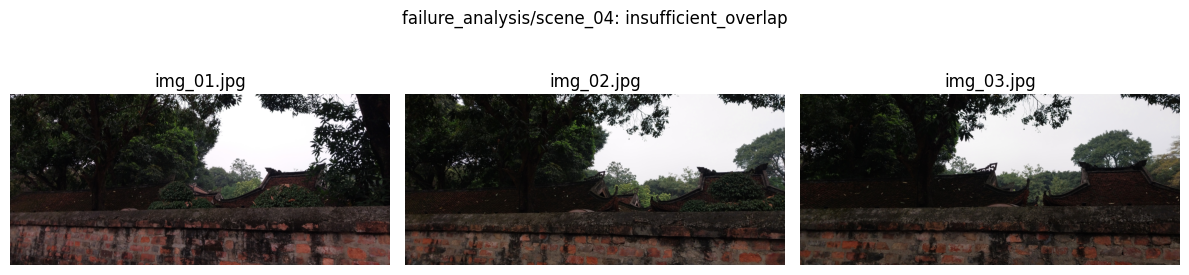

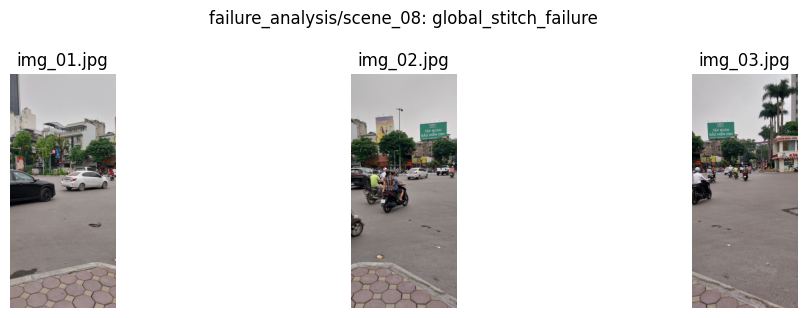

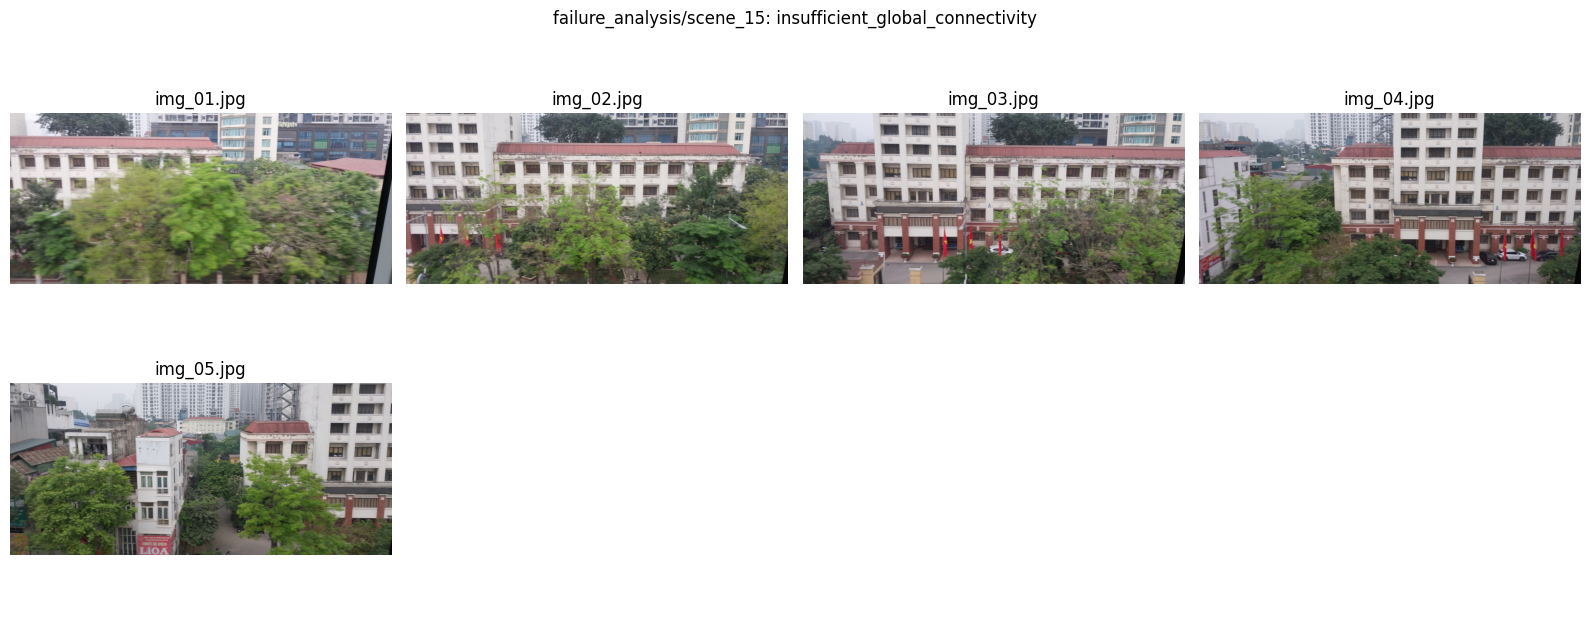

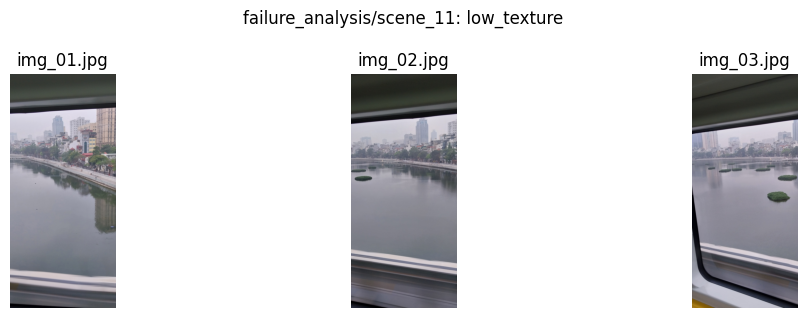

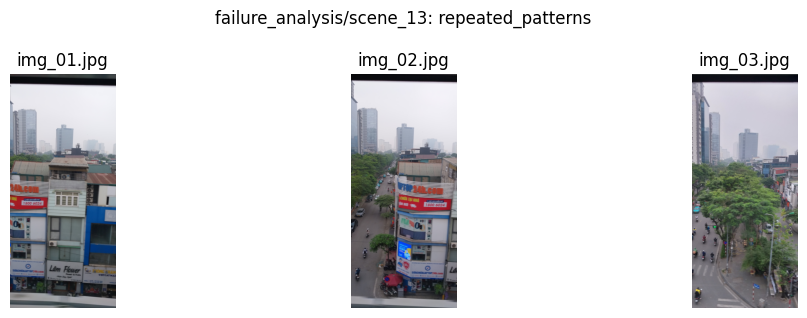

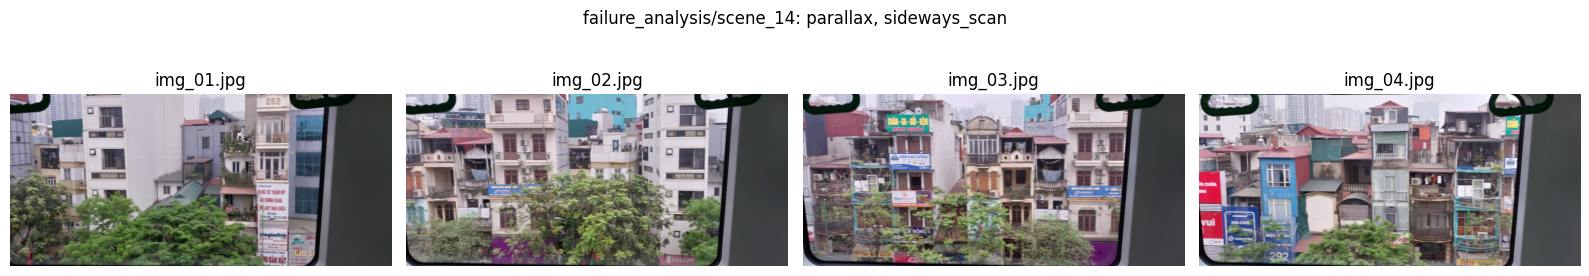

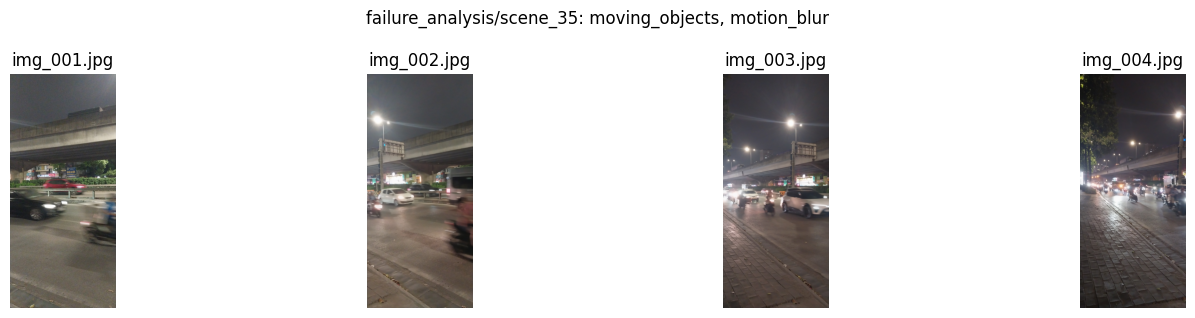

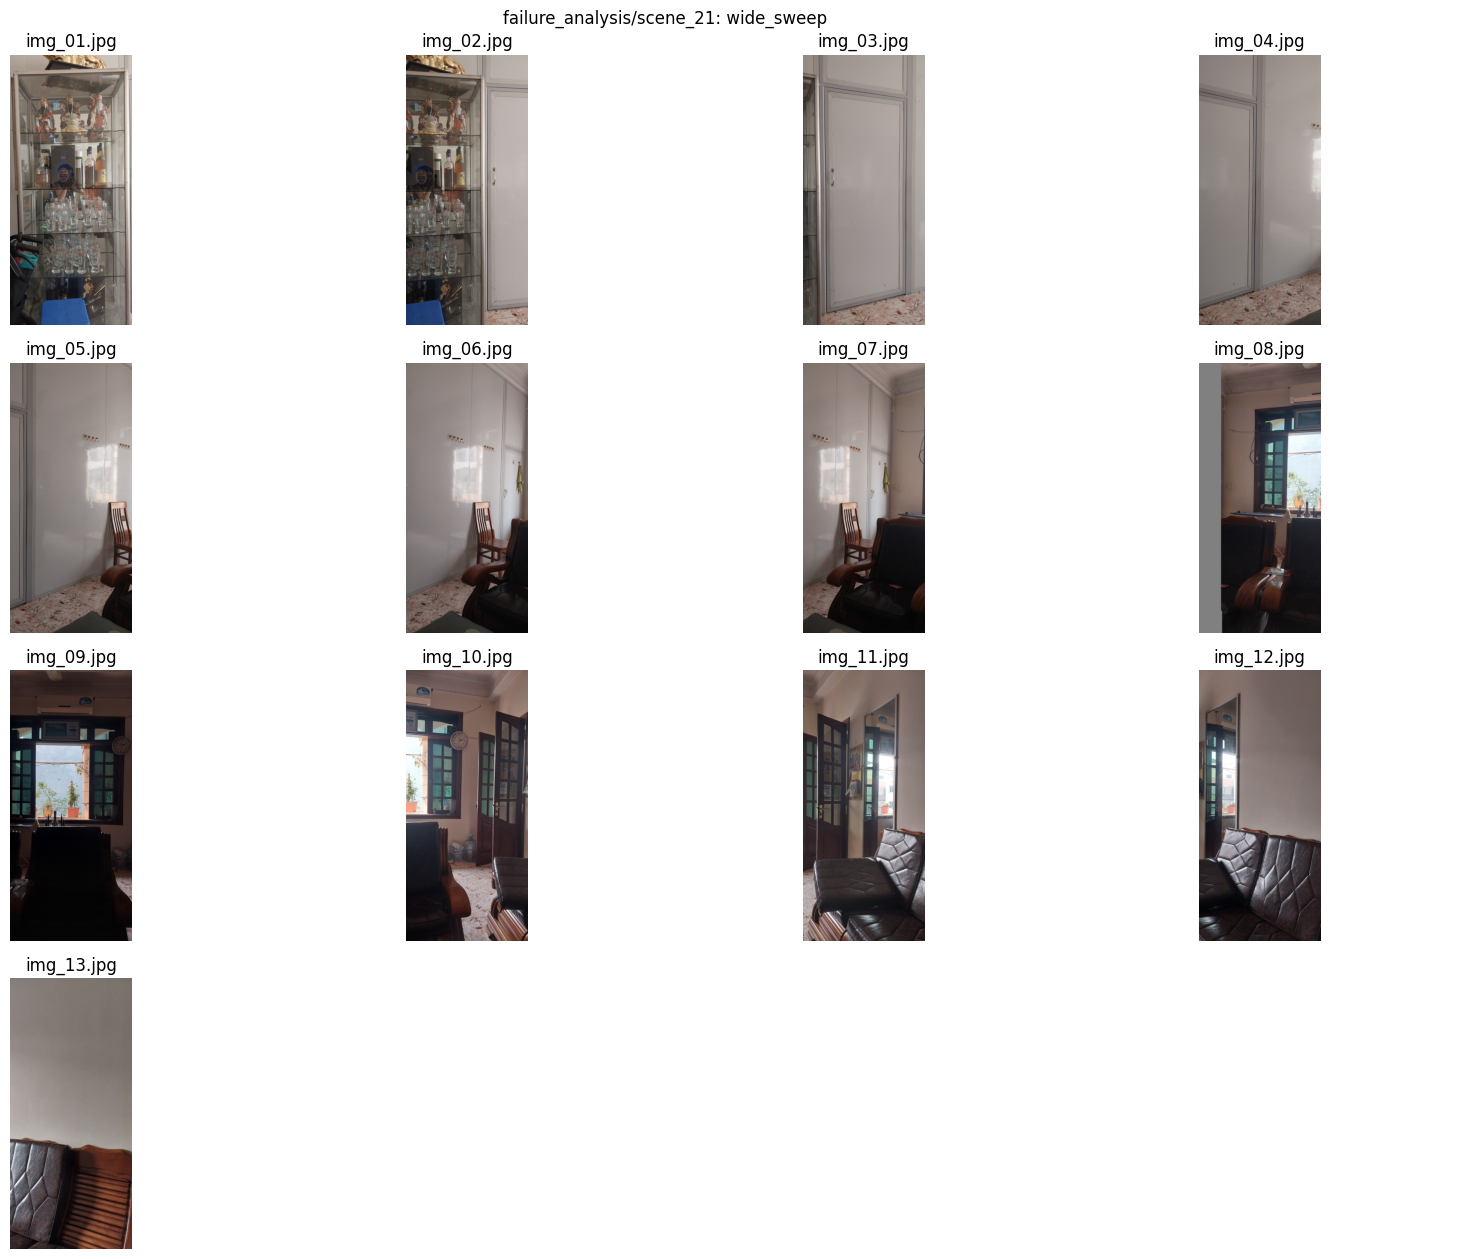

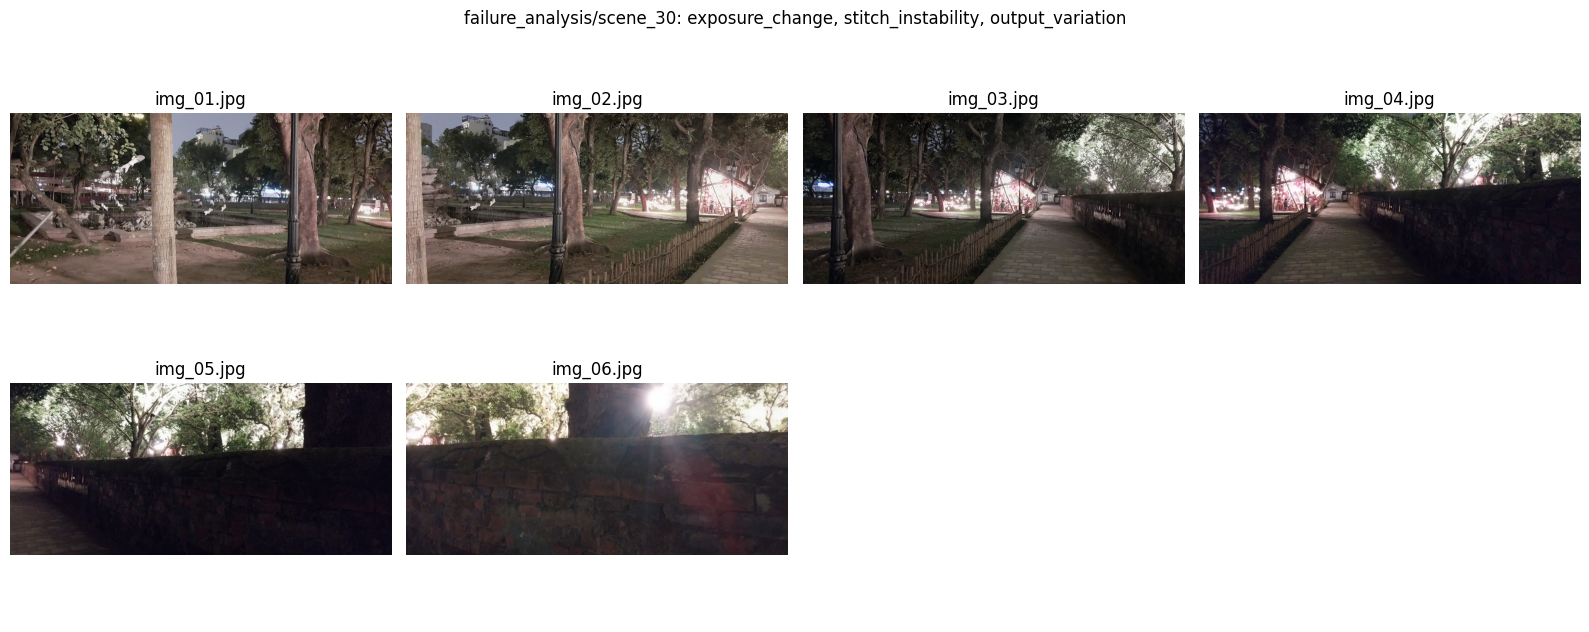

In [15]:
FAILURE_CASE_EXAMPLES = [
    {
        'failure_case': 'insufficient_overlap',
        'scene_id': 'scene_04',
        'why_this_scene': 'pure overlap failure with minimal extra confounds',
    },
    {
        'failure_case': 'global_stitch_failure',
        'scene_id': 'scene_08',
        'why_this_scene': 'clear global failure despite adjacent evidence',
    },
    {
        'failure_case': 'insufficient_global_connectivity',
        'scene_id': 'scene_15',
        'why_this_scene': 'chain breaks at global level even though local views exist',
    },
    {
        'failure_case': 'low_texture',
        'scene_id': 'scene_11',
        'why_this_scene': 'cleanest low-texture failure in the split dataset',
    },
    {
        'failure_case': 'repeated_patterns',
        'scene_id': 'scene_13',
        'why_this_scene': 'strong repetitive structure causes ambiguous matching',
    },
    {
        'failure_case': 'parallax',
        'scene_id': 'scene_14',
        'why_this_scene': 'foreground/background geometry shifts clearly across the scan',
    },
    {
        'failure_case': 'sideways_scan',
        'scene_id': 'scene_14',
        'why_this_scene': 'representative moving-platform capture instead of rotate-in-place panorama',
    },
    {
        'failure_case': 'moving_objects',
        'scene_id': 'scene_35',
        'why_this_scene': 'dynamic traffic is obvious and easy to explain visually',
    },
    {
        'failure_case': 'motion_blur',
        'scene_id': 'scene_35',
        'why_this_scene': 'night blur is visually obvious and easy to connect to weak matching',
    },
    {
        'failure_case': 'wide_sweep',
        'scene_id': 'scene_21',
        'why_this_scene': 'large sweep with difficult global consistency',
    },
    {
        'failure_case': 'exposure_change',
        'scene_id': 'scene_30',
        'why_this_scene': 'clear brightness shift between adjacent frames',
    },
    {
        'failure_case': 'stitch_instability',
        'scene_id': 'scene_30',
        'why_this_scene': 'same scene is stable enough to inspect but unstable enough to discuss output inconsistency',
    },
    {
        'failure_case': 'output_variation',
        'scene_id': 'scene_30',
        'why_this_scene': 'good representative for visible output changes across repeated runs',
    },
]


def show_scene_preview_row(
    scene_id: str,
    represented_cases: list[str],
    split_name: str | None = None,
    max_images: int | None = None,
    max_cols: int = 4,
) -> None:
    try:
        scene_dir = resolve_scene_dir(scene_id, split_name=split_name)
    except FileNotFoundError as exc:
        print(f'Skipping {scene_id}: {exc}')
        return

    files = list_image_files(scene_dir)
    if not files:
        print(f'No ordered images found for {scene_id}')
        return

    preview_files = files if max_images is None else files[:max_images]
    if not preview_files:
        print(f'No images selected for {scene_id}')
        return

    cols = min(max_cols, len(preview_files))
    rows = (len(preview_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows))
    axes_array = np.array(axes).reshape(-1)

    for ax, path in zip(axes_array, preview_files):
        image_bgr = load_bgr(path, max_long_edge=900)
        ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(path.name)
        ax.axis('off')

    for ax in axes_array[len(preview_files):]:
        ax.axis('off')

    suffix = ''
    if len(files) > len(preview_files):
        suffix = f' (+{len(files) - len(preview_files)} more images)'
    fig.suptitle(f"{scene_dir.parent.name}/{scene_id}: {', '.join(represented_cases)}{suffix}", fontsize=12)
    plt.tight_layout()
    plt.show()

failure_split_scene_ids = {path.name for path in list_scene_dirs(DATA_ROOT / 'failure_analysis')}

example_rows = []
for item in FAILURE_CASE_EXAMPLES:
    scene_id = item['scene_id']
    try:
        scene_dir = resolve_scene_dir(scene_id)
    except FileNotFoundError:
        continue
    meta = load_scene_meta_file(scene_dir) or {}
    example_rows.append(
        {
            'failure_case': item['failure_case'],
            'split': scene_dir.parent.name,
            'scene_id': scene_id,
            'meta_category': meta.get('category'),
            'meta_difficulty': meta.get('difficulty'),
            'scene_issues': ', '.join(meta.get('issues', [])),
            'in_failure_split': scene_id in failure_split_scene_ids,
            'why_this_scene': item['why_this_scene'],
        }
    )

print('Representative failure-case scenes from the split dataset:')
display(pd.DataFrame(example_rows))

print('\nVisual gallery of representative scenes:')
unique_scene_ids = []
for item in FAILURE_CASE_EXAMPLES:
    if item['scene_id'] not in unique_scene_ids:
        unique_scene_ids.append(item['scene_id'])

for scene_id in unique_scene_ids:
    represented_cases = [item['failure_case'] for item in FAILURE_CASE_EXAMPLES if item['scene_id'] == scene_id]
    show_scene_preview_row(scene_id, represented_cases, split_name='failure_analysis')


## Section 16. Diagnostic Plots

Histogram và bảng đếm ở đây giúp tune threshold.

Nếu audit nhiều methods, notebook sẽ:
- plot histogram theo `PRIMARY_FEATURE_METHOD`
- đồng thời hiển thị bảng đếm theo từng method để compare nhanh


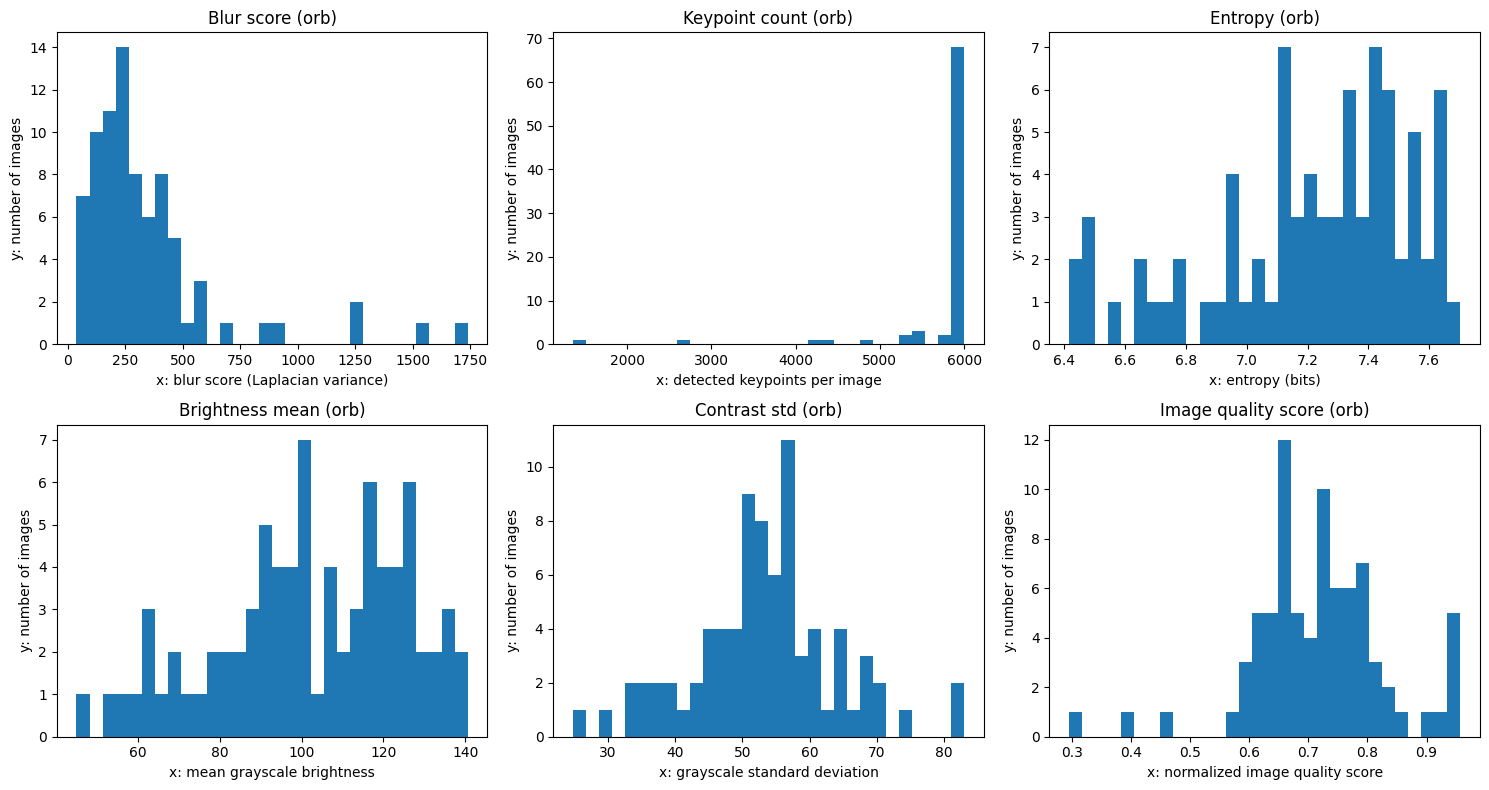

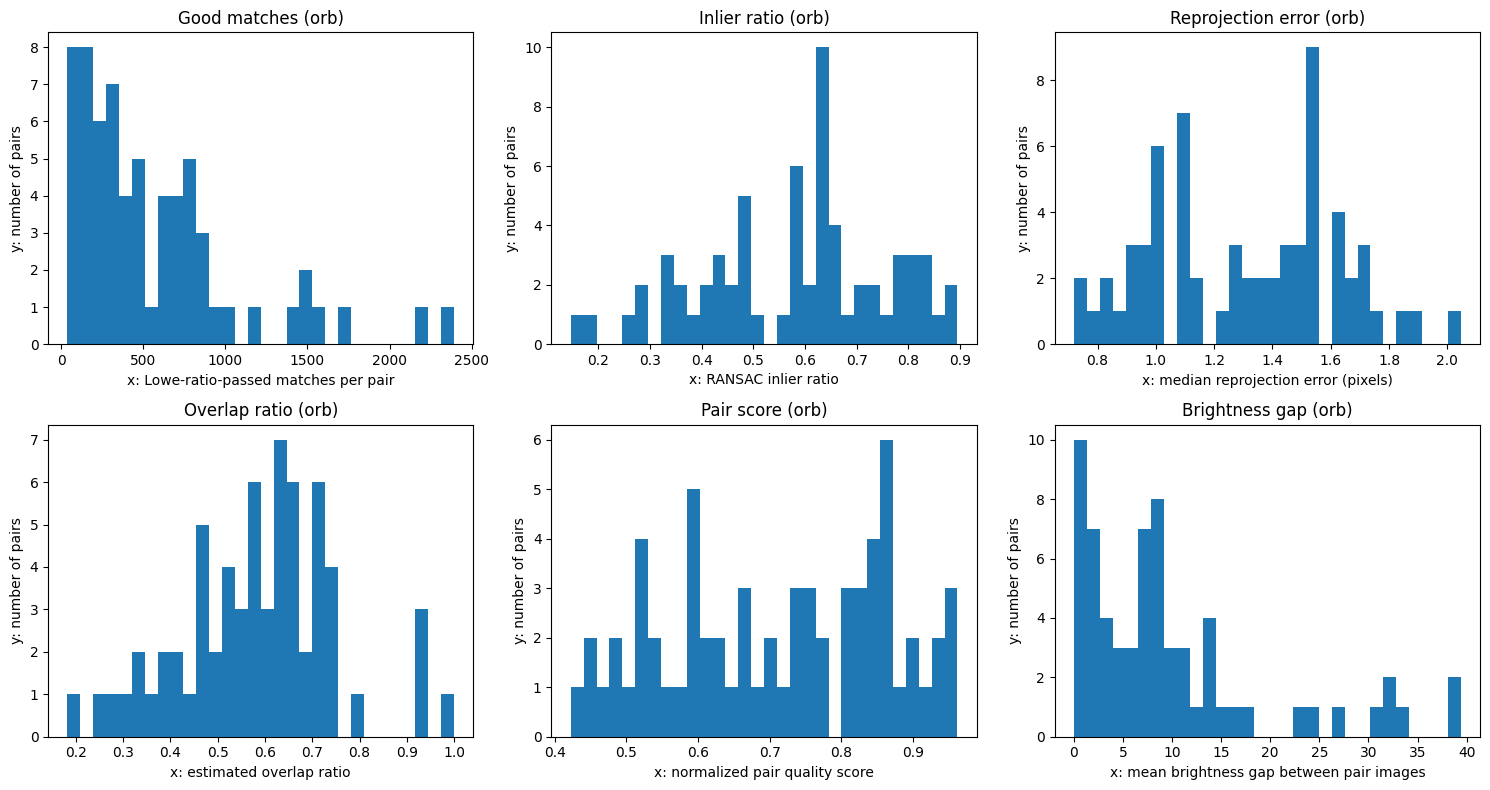


Success vs failure comparison (strict metadata categories only; `hard_valid` scenes excluded):


,meta_category,num_scenes
0,failure,6
1,success,5


C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\PC\

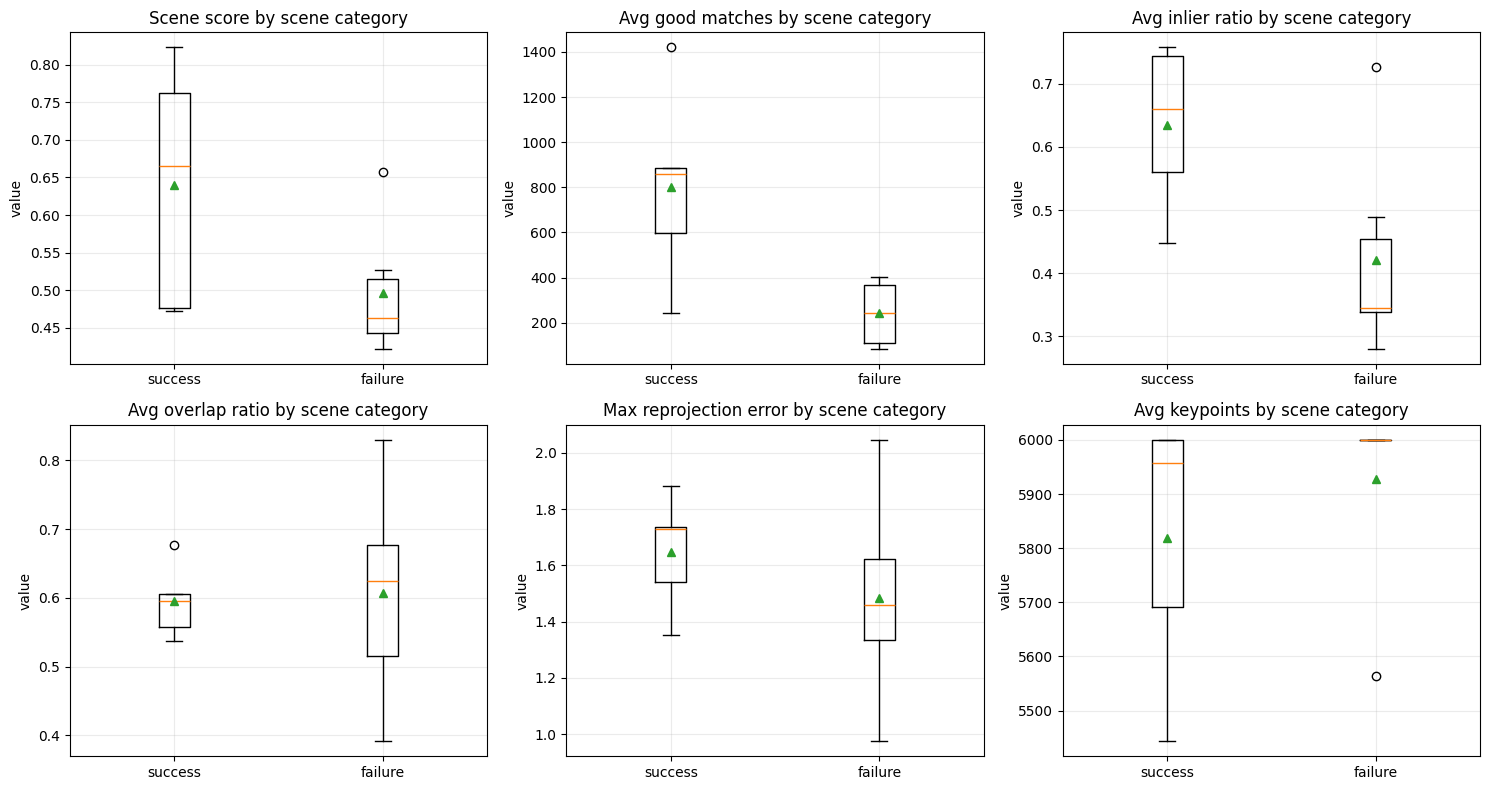

C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users

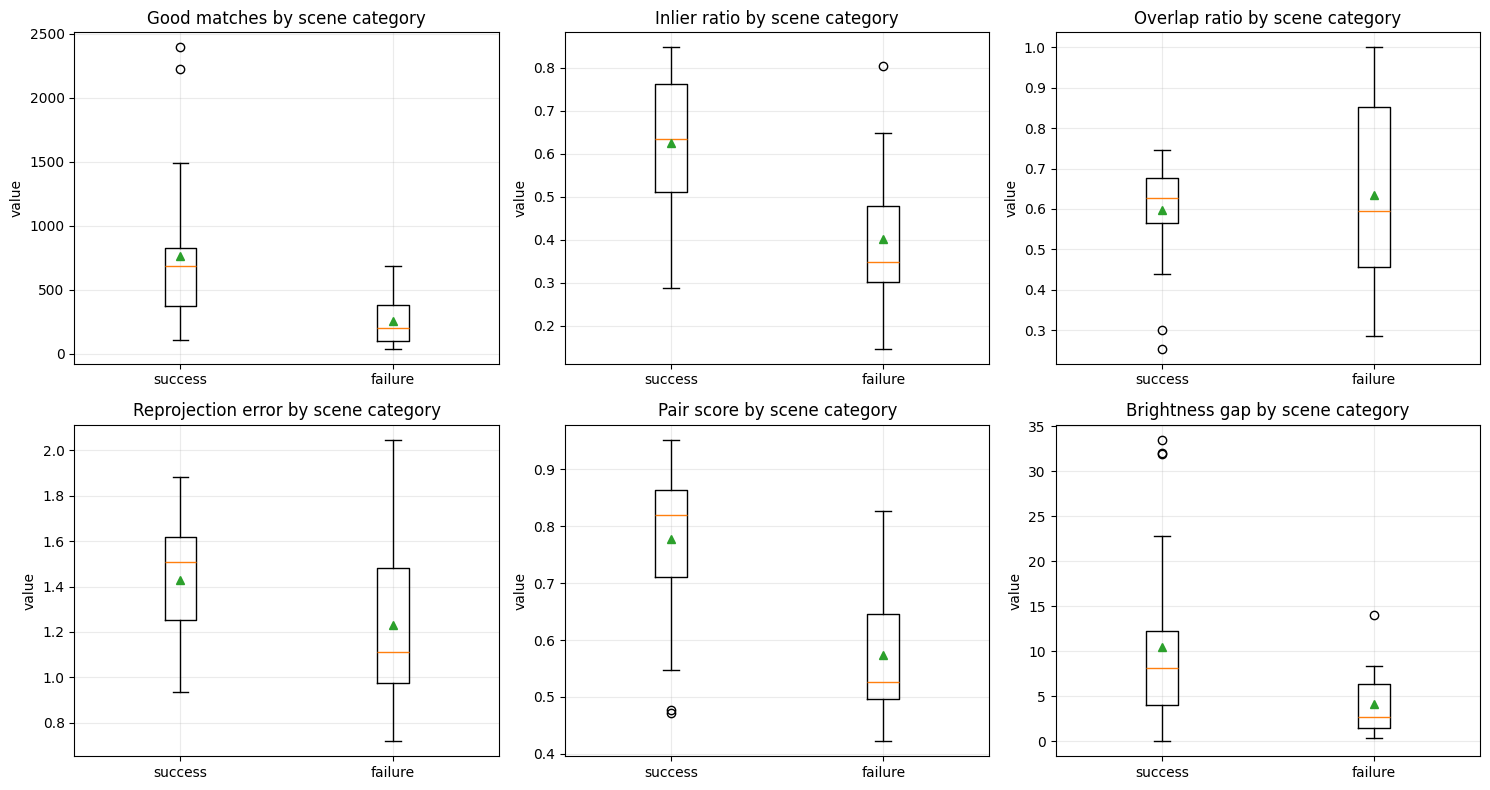


Success vs hard_valid vs failure comparison (metadata categories):


,meta_category,num_scenes
0,success,5
1,hard_valid,4
2,failure,6


C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_category, labels=labels, showmeans=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_category, labels=labels, showmeans=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_category, labels=labels, showmeans=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:176: MatplotlibDeprecationWarning: The 'labels

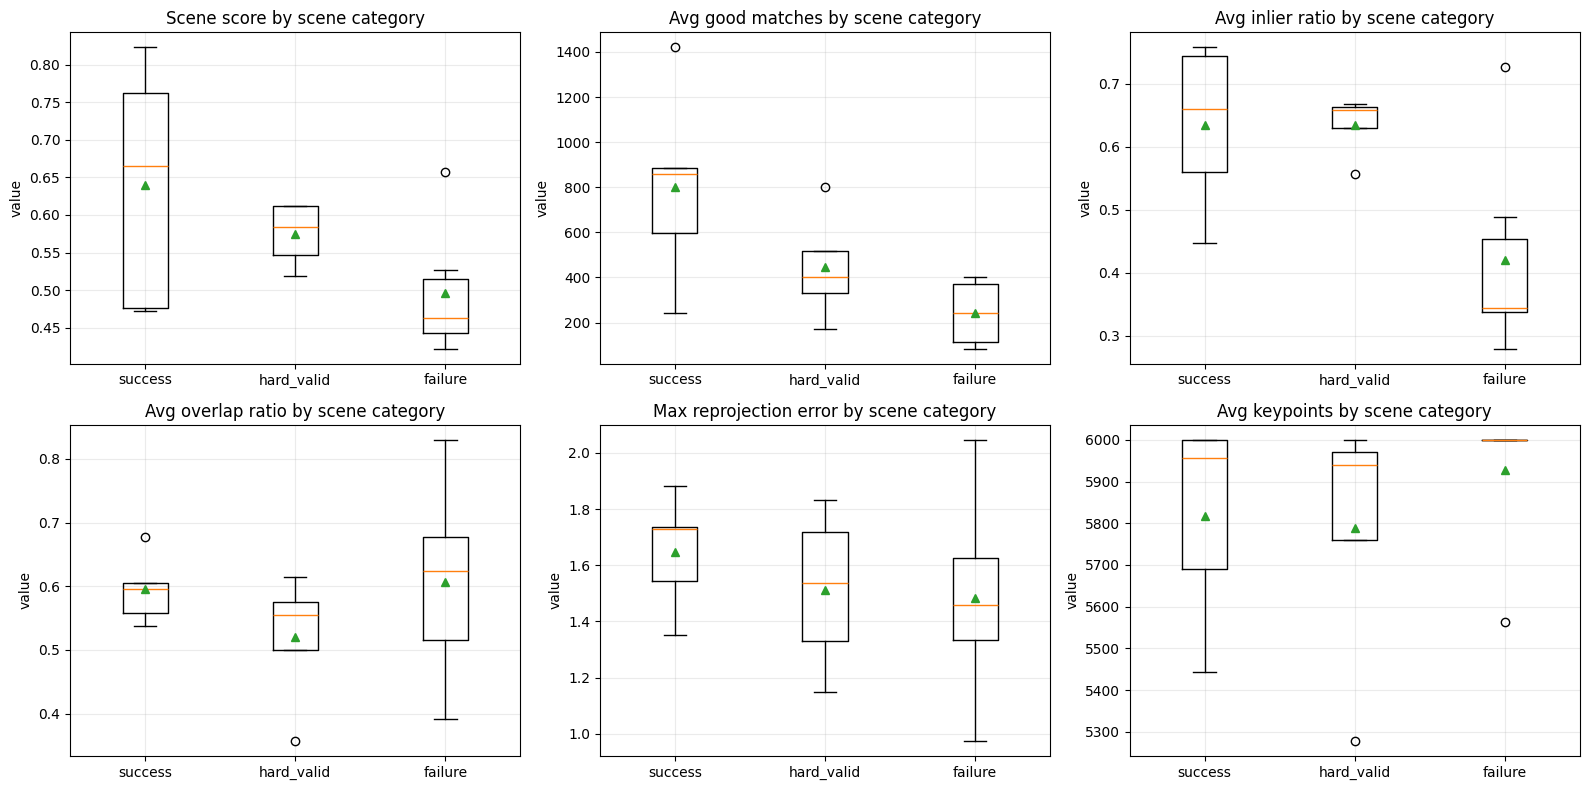

C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_category, labels=labels, showmeans=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_category, labels=labels, showmeans=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_category, labels=labels, showmeans=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_5372\1349591928.py:210: MatplotlibDeprecationWarning: The 'labels

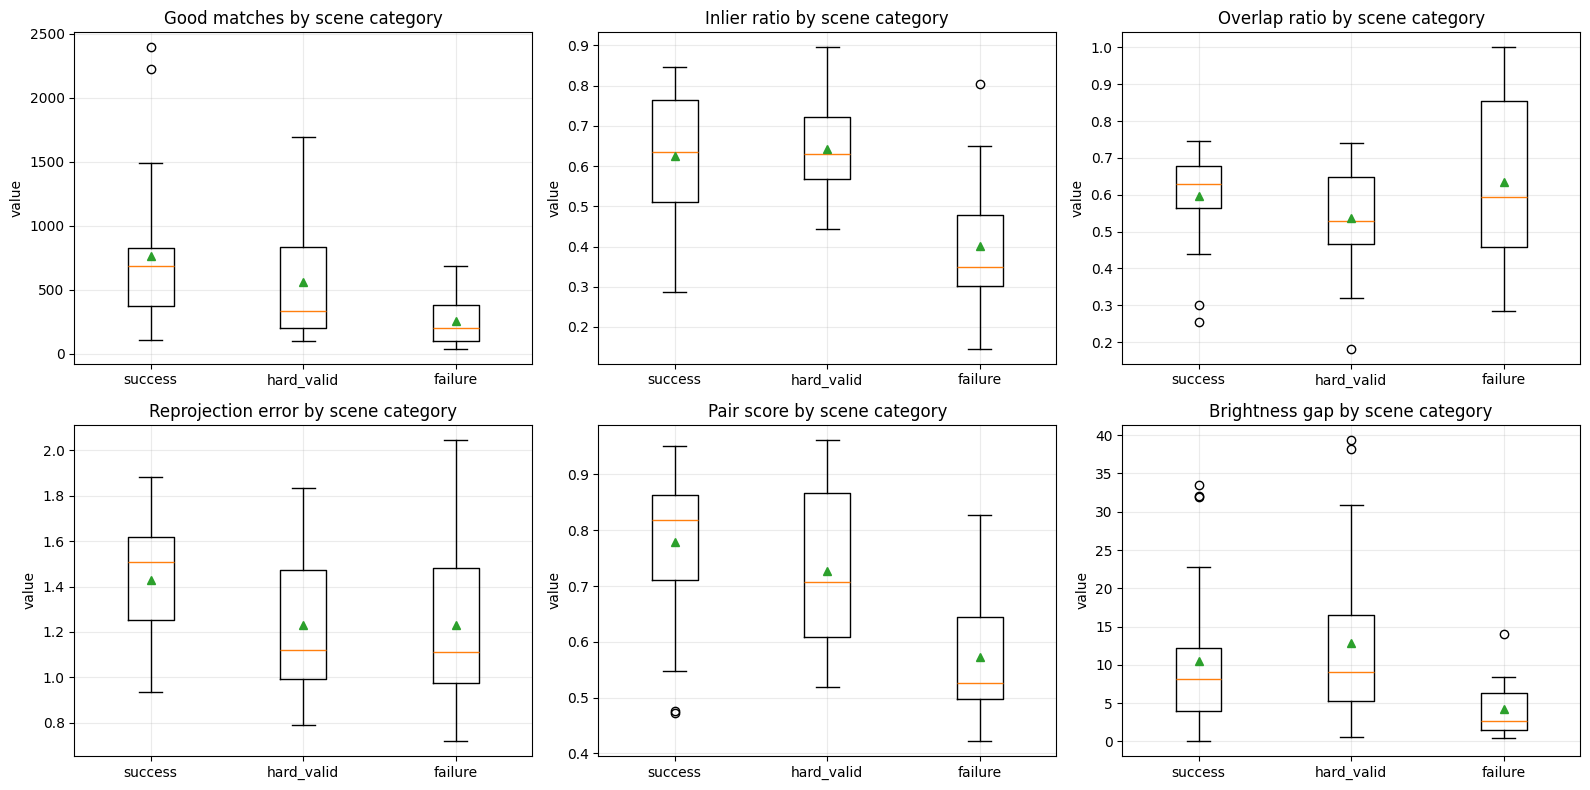

Table legend: rows = feature methods, columns = scene labels / audit-vs-OpenCV buckets, values = number of scenes


scene_label,borderline,likely_fail
feature_method,,
orb,8,7


audit_vs_opencv,aligned,aligned_ok_with_risk,audit_more_conservative,needs_manual_judgment
feature_method,,,,
orb,5,6,2,2


Table legend: rows = feature methods, columns = pair labels, values = number of pairs


pair_label,fail,ok,strong,weak
feature_method,,,,
orb,12,13,14,26


In [16]:
plot_images = df_images
plot_pairs = df_pairs
plot_scenes = df_scenes

if not df_images.empty and 'feature_method' in df_images and df_images['feature_method'].nunique() > 1:
    plot_images = df_images[df_images['feature_method'] == PRIMARY_FEATURE_METHOD]
if not df_pairs.empty and 'feature_method' in df_pairs and df_pairs['feature_method'].nunique() > 1:
    plot_pairs = df_pairs[df_pairs['feature_method'] == PRIMARY_FEATURE_METHOD]
if not df_scenes.empty and 'feature_method' in df_scenes and df_scenes['feature_method'].nunique() > 1:
    plot_scenes = df_scenes[df_scenes['feature_method'] == PRIMARY_FEATURE_METHOD]

if not plot_images.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].hist(plot_images['blur_score'], bins=30)
    axes[0, 0].set_title(f'Blur score ({PRIMARY_FEATURE_METHOD})')
    axes[0, 0].set_xlabel('x: blur score (Laplacian variance)')
    axes[0, 0].set_ylabel('y: number of images')
    axes[0, 1].hist(plot_images['keypoints'], bins=30)
    axes[0, 1].set_title(f'Keypoint count ({PRIMARY_FEATURE_METHOD})')
    axes[0, 1].set_xlabel('x: detected keypoints per image')
    axes[0, 1].set_ylabel('y: number of images')
    axes[0, 2].hist(plot_images['entropy'], bins=30)
    axes[0, 2].set_title(f'Entropy ({PRIMARY_FEATURE_METHOD})')
    axes[0, 2].set_xlabel('x: entropy (bits)')
    axes[0, 2].set_ylabel('y: number of images')
    axes[1, 0].hist(plot_images['brightness_mean'], bins=30)
    axes[1, 0].set_title(f'Brightness mean ({PRIMARY_FEATURE_METHOD})')
    axes[1, 0].set_xlabel('x: mean grayscale brightness')
    axes[1, 0].set_ylabel('y: number of images')
    axes[1, 1].hist(plot_images['contrast_std'], bins=30)
    axes[1, 1].set_title(f'Contrast std ({PRIMARY_FEATURE_METHOD})')
    axes[1, 1].set_xlabel('x: grayscale standard deviation')
    axes[1, 1].set_ylabel('y: number of images')
    axes[1, 2].hist(plot_images['image_quality_score'], bins=30)
    axes[1, 2].set_title(f'Image quality score ({PRIMARY_FEATURE_METHOD})')
    axes[1, 2].set_xlabel('x: normalized image quality score')
    axes[1, 2].set_ylabel('y: number of images')
    plt.tight_layout()
    plt.show()

if not plot_pairs.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].hist(plot_pairs['good_matches'], bins=30)
    axes[0, 0].set_title(f'Good matches ({PRIMARY_FEATURE_METHOD})')
    axes[0, 0].set_xlabel('x: Lowe-ratio-passed matches per pair')
    axes[0, 0].set_ylabel('y: number of pairs')
    axes[0, 1].hist(plot_pairs['inlier_ratio'], bins=30)
    axes[0, 1].set_title(f'Inlier ratio ({PRIMARY_FEATURE_METHOD})')
    axes[0, 1].set_xlabel('x: RANSAC inlier ratio')
    axes[0, 1].set_ylabel('y: number of pairs')
    valid_reproj = plot_pairs[np.isfinite(plot_pairs['reprojection_error'])]['reprojection_error']
    axes[0, 2].hist(valid_reproj, bins=30)
    axes[0, 2].set_title(f'Reprojection error ({PRIMARY_FEATURE_METHOD})')
    axes[0, 2].set_xlabel('x: median reprojection error (pixels)')
    axes[0, 2].set_ylabel('y: number of pairs')
    axes[1, 0].hist(plot_pairs['overlap_ratio'], bins=30)
    axes[1, 0].set_title(f'Overlap ratio ({PRIMARY_FEATURE_METHOD})')
    axes[1, 0].set_xlabel('x: estimated overlap ratio')
    axes[1, 0].set_ylabel('y: number of pairs')
    axes[1, 1].hist(plot_pairs['pair_score'], bins=30)
    axes[1, 1].set_title(f'Pair score ({PRIMARY_FEATURE_METHOD})')
    axes[1, 1].set_xlabel('x: normalized pair quality score')
    axes[1, 1].set_ylabel('y: number of pairs')
    axes[1, 2].hist(plot_pairs['brightness_gap'], bins=30)
    axes[1, 2].set_title(f'Brightness gap ({PRIMARY_FEATURE_METHOD})')
    axes[1, 2].set_xlabel('x: mean brightness gap between pair images')
    axes[1, 2].set_ylabel('y: number of pairs')
    plt.tight_layout()
    plt.show()

comparison_scenes = pd.DataFrame()
if not plot_scenes.empty and 'meta_category' in plot_scenes:
    comparison_scenes = plot_scenes[plot_scenes['meta_category'].isin(['success', 'failure'])].copy()

if not comparison_scenes.empty and comparison_scenes['meta_category'].nunique() == 2:
    print("\nSuccess vs failure comparison (strict metadata categories only; `hard_valid` scenes excluded):")
    display(comparison_scenes.groupby('meta_category').size().rename('num_scenes').reset_index())

    scene_compare_metrics = [
        ('scene_score', 'Scene score'),
        ('avg_good_matches', 'Avg good matches'),
        ('avg_inlier_ratio', 'Avg inlier ratio'),
        ('avg_overlap_ratio', 'Avg overlap ratio'),
        ('max_reprojection_error', 'Max reprojection error'),
        ('avg_keypoints', 'Avg keypoints'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (column, title) in zip(axes.flat, scene_compare_metrics):
        success_values = comparison_scenes.loc[comparison_scenes['meta_category'] == 'success', column]
        failure_values = comparison_scenes.loc[comparison_scenes['meta_category'] == 'failure', column]
        success_values = success_values[np.isfinite(success_values)]
        failure_values = failure_values[np.isfinite(failure_values)]
        ax.boxplot(
            [success_values.values, failure_values.values],
            labels=['success', 'failure'],
            showmeans=True,
        )
        ax.set_title(f'{title} by scene category')
        ax.set_ylabel('value')
        ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    pair_compare = plot_pairs.merge(
        comparison_scenes[['scene_id', 'meta_category']].drop_duplicates(),
        on='scene_id',
        how='inner',
    ) if not plot_pairs.empty else pd.DataFrame()
    pair_compare = pair_compare[pair_compare['pair_gap'] == 1] if not pair_compare.empty and 'pair_gap' in pair_compare else pair_compare

    if not pair_compare.empty:
        pair_compare_metrics = [
            ('good_matches', 'Good matches'),
            ('inlier_ratio', 'Inlier ratio'),
            ('overlap_ratio', 'Overlap ratio'),
            ('reprojection_error', 'Reprojection error'),
            ('pair_score', 'Pair score'),
            ('brightness_gap', 'Brightness gap'),
        ]
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        for ax, (column, title) in zip(axes.flat, pair_compare_metrics):
            success_values = pair_compare.loc[pair_compare['meta_category'] == 'success', column]
            failure_values = pair_compare.loc[pair_compare['meta_category'] == 'failure', column]
            success_values = success_values[np.isfinite(success_values)]
            failure_values = failure_values[np.isfinite(failure_values)]
            ax.boxplot(
                [success_values.values, failure_values.values],
                labels=['success', 'failure'],
                showmeans=True,
            )
            ax.set_title(f'{title} by scene category')
            ax.set_ylabel('value')
            ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
else:
    print("\nNeed both `success` and `failure` scenes in the current dataframe to plot success-vs-failure comparisons.")

comparison_scenes_3way = pd.DataFrame()
if not plot_scenes.empty and 'meta_category' in plot_scenes:
    comparison_scenes_3way = plot_scenes[plot_scenes['meta_category'].isin(['success', 'hard_valid', 'failure'])].copy()

category_order = []
if not comparison_scenes_3way.empty:
    present_categories = set(comparison_scenes_3way['meta_category'].dropna().unique())
    category_order = [label for label in ['success', 'hard_valid', 'failure'] if label in present_categories]

if len(category_order) >= 2:
    print("\nSuccess vs hard_valid vs failure comparison (metadata categories):")
    display(
        comparison_scenes_3way.groupby('meta_category').size()
        .reindex(category_order, fill_value=0)
        .rename('num_scenes')
        .reset_index()
    )

    scene_compare_metrics_3way = [
        ('scene_score', 'Scene score'),
        ('avg_good_matches', 'Avg good matches'),
        ('avg_inlier_ratio', 'Avg inlier ratio'),
        ('avg_overlap_ratio', 'Avg overlap ratio'),
        ('max_reprojection_error', 'Max reprojection error'),
        ('avg_keypoints', 'Avg keypoints'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, (column, title) in zip(axes.flat, scene_compare_metrics_3way):
        values_by_category = []
        labels = []
        for category in category_order:
            values = comparison_scenes_3way.loc[comparison_scenes_3way['meta_category'] == category, column]
            values = values[np.isfinite(values)]
            if len(values) > 0:
                values_by_category.append(values.values)
                labels.append(category)
        if values_by_category:
            ax.boxplot(values_by_category, labels=labels, showmeans=True)
        ax.set_title(f'{title} by scene category')
        ax.set_ylabel('value')
        ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    pair_compare_3way = plot_pairs.merge(
        comparison_scenes_3way[['scene_id', 'meta_category']].drop_duplicates(),
        on='scene_id',
        how='inner',
    ) if not plot_pairs.empty else pd.DataFrame()
    pair_compare_3way = pair_compare_3way[pair_compare_3way['pair_gap'] == 1] if not pair_compare_3way.empty and 'pair_gap' in pair_compare_3way else pair_compare_3way

    if not pair_compare_3way.empty:
        pair_compare_metrics_3way = [
            ('good_matches', 'Good matches'),
            ('inlier_ratio', 'Inlier ratio'),
            ('overlap_ratio', 'Overlap ratio'),
            ('reprojection_error', 'Reprojection error'),
            ('pair_score', 'Pair score'),
            ('brightness_gap', 'Brightness gap'),
        ]
        fig, axes = plt.subplots(2, 3, figsize=(16, 8))
        for ax, (column, title) in zip(axes.flat, pair_compare_metrics_3way):
            values_by_category = []
            labels = []
            for category in category_order:
                values = pair_compare_3way.loc[pair_compare_3way['meta_category'] == category, column]
                values = values[np.isfinite(values)]
                if len(values) > 0:
                    values_by_category.append(values.values)
                    labels.append(category)
            if values_by_category:
                ax.boxplot(values_by_category, labels=labels, showmeans=True)
            ax.set_title(f'{title} by scene category')
            ax.set_ylabel('value')
            ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
else:
    print("\nNeed at least two of `success`, `hard_valid`, and `failure` in the current dataframe to plot the 3-way comparison.")

if not df_scenes.empty and 'feature_method' in df_scenes:
    print('Table legend: rows = feature methods, columns = scene labels / audit-vs-OpenCV buckets, values = number of scenes')
    display(df_scenes.groupby(['feature_method', 'scene_label']).size().unstack(fill_value=0))
    display(df_scenes.groupby(['feature_method', 'audit_vs_opencv']).size().unstack(fill_value=0))
if not df_pairs.empty and 'feature_method' in df_pairs:
    print('Table legend: rows = feature methods, columns = pair labels, values = number of pairs')
    display(df_pairs.groupby(['feature_method', 'pair_label']).size().unstack(fill_value=0))


## Section 17. Inspect One Scene Manually

Đây là cell để đào sâu một scene cụ thể sau khi auto-audit.

Điểm mới:
- inspect theo `feature_method`
- nếu scene chưa có trong dataframe hiện tại, notebook có thể audit on-the-fly
- hiển thị cả inventory context và preprocessing outlook


In [17]:
SCENE_TO_INSPECT = None  # e.g. 'scene_08'
INSPECT_SPLIT = None  # e.g. 'failure_analysis'; leave None if scene_id is unique across splits
INSPECT_FEATURE_METHOD = PRIMARY_FEATURE_METHOD


def filter_scene_rows(df: pd.DataFrame, scene_id: str, split_name: str, feature_method: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    mask = (df['scene_id'] == scene_id) & (df['feature_method'] == feature_method)
    if 'split' in df.columns:
        mask = mask & (df['split'] == split_name)
    return df[mask]


if SCENE_TO_INSPECT:
    scene_dir = resolve_scene_dir(SCENE_TO_INSPECT, split_name=INSPECT_SPLIT)
    resolved_split = scene_dir.parent.name
    meta_context = summarize_inventory(scene_dir)
    meta_context['split'] = resolved_split
    display(pd.DataFrame([meta_context]))

    scene_rows_selected = filter_scene_rows(df_scenes, SCENE_TO_INSPECT, resolved_split, INSPECT_FEATURE_METHOD)
    pair_rows_selected = filter_scene_rows(df_pairs, SCENE_TO_INSPECT, resolved_split, INSPECT_FEATURE_METHOD)
    skip_rows_selected = filter_scene_rows(df_skip_pairs, SCENE_TO_INSPECT, resolved_split, INSPECT_FEATURE_METHOD)
    image_rows_selected = filter_scene_rows(df_images, SCENE_TO_INSPECT, resolved_split, INSPECT_FEATURE_METHOD)

    if scene_rows_selected.empty:
        temp_image_rows, temp_pair_rows, temp_skip_rows, temp_scene_row = audit_scene(
            scene_dir,
            feature_method=INSPECT_FEATURE_METHOD,
            save_visuals=False,
        )
        attach_split(temp_image_rows, resolved_split)
        attach_split(temp_pair_rows, resolved_split)
        attach_split(temp_skip_rows, resolved_split)
        temp_scene_row['split'] = resolved_split
        scene_rows_selected = pd.DataFrame([temp_scene_row])
        pair_rows_selected = pd.DataFrame(temp_pair_rows)
        skip_rows_selected = pd.DataFrame(temp_skip_rows)
        image_rows_selected = pd.DataFrame(temp_image_rows)

    display(scene_rows_selected.reset_index(drop=True))

    files = list_image_files(scene_dir)
    reference_files = list_reference_files(scene_dir)
    print('Split:', resolved_split)
    print('Ordered files:', [path.name for path in files])
    if reference_files:
        print('Reference files (excluded from audit chain):', [path.name for path in reference_files])

    for path in files:
        show_bgr(load_bgr(path), title=f'{resolved_split}/{SCENE_TO_INSPECT} - {path.name}')

    if reference_files:
        for path in reference_files:
            show_bgr(load_bgr(path), title=f'{resolved_split}/{SCENE_TO_INSPECT} - reference - {path.name}')

    print("\nImage metrics:")
    display(image_rows_selected.sort_values(['image_id']).reset_index(drop=True))

    print("\nAdjacent pair metrics:")
    display(pair_rows_selected[pair_rows_selected['pair_gap'] == 1].sort_values(['pair_score']).reset_index(drop=True))

    print("\nSkip-pair metrics:")
    display(skip_rows_selected.sort_values(['pair_score']).reset_index(drop=True))
else:
    print('Set SCENE_TO_INSPECT to inspect one scene after the split audit.')


Set SCENE_TO_INSPECT to inspect one scene after the split audit.


## Interpretation

### `inventory_status`
- `ok`: thứ tự và inventory của scene nhìn đáng tin
- `warning`: scene vẫn audit được nhưng nên kiểm actual files / order / reference shots
- `error`: inventory có vấn đề đủ lớn để không nên tin scene-level conclusion hoàn toàn

### `likely_good`
- adjacent pairs sạch tương đối đồng đều
- không có `skip-pair` gãy rõ
- không có transform sanity fail đáng kể
- thường sẵn sàng cho phase preprocessing hoặc stitching baseline

### `borderline`
- có ít nhất một mắt xích yếu
- hoặc orientation / transform sanity bắt đầu đáng ngại
- hoặc pairwise ổn nhưng `skip-pair` cho thấy chuỗi toàn cục chưa thật sạch

### `likely_fail`
- có pair fail cứng
- hoặc inventory invalid
- hoặc chain có dấu hiệu gãy ở mức toàn cục / transform fail rõ

### `scene_preprocess_recommendations`
- đây là danh sách action-oriented để nối sang notebook preprocessing
- nếu xuất hiện `recapture_*` hoặc `split_scene_*` thì scene đó không chỉ thiếu preprocessing, mà còn có vấn đề capture / chain geometry

### `audit_vs_opencv`
- `aligned`: audit và OpenCV kể cùng một câu chuyện
- `audit_more_optimistic`: pairwise audit vẫn đang lạc quan hơn stitch thật
- `audit_more_conservative`: audit nghiêm hơn stitch thật
- `needs_manual_judgment`: scene ở vùng xám, nên xem trực tiếp
